# Vietnam Statistical Arbitrage: PCA + OU Mean Reversion
## Baseline Notebook (Long-Only + VN30 Futures Hedge)

This notebook implements a statistical arbitrage strategy for Vietnam stocks:
- **Factor Model**: Rolling PCA on stock returns
- **Signal**: OU/AR(1) mean-reversion fitted to residuals
- **Portfolio**: Long-only, equal-weight, VN30-hedged
- **Goal**: Validate the research pipeline before optimization

Pipeline:
1. Data loading & preprocessing
2. Universe definition
3. Rolling PCA factor extraction
4. Residual construction
5. OU/AR(1) mean-reversion fitting
6. S-score signal generation
7. Long-only signal logic
8. Equal-weight portfolio construction
9. VN30 futures hedge computation
10. Backtest engine
11. Performance analysis & diagnostics

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Libraries loaded successfully.
Pandas: 2.3.3
NumPy: 2.4.3


# SECTION 1: Data Loading and Preprocessing
## Vietnam stocks + VN30 futures prices, volumes, and returns

In [166]:
# =============================================================================
# COMPREHENSIVE FUNCTION LIBRARY (from stat_arb_backtest_v5.py)
# Statistical Arbitrage Framework - Vietnam Long-Only Strategy
# **CURRENCY: All monetary values in thousands of VND (K VND)**
# =============================================================================

# --- 1. DATA PREPARATION AND UNIVERSE SELECTION ---

def select_universe(stock_price_df: pd.DataFrame, stock_volume_df: pd.DataFrame):
    """
    Clean stock data without creating fake tradability.
    
    Steps:
    1. Remove stocks with >5% missing data
    2. Check for 95% valid ratio on remaining stocks
    3. NO forward-fill of prices or volume - preserves trading reality
    
    Returns:
    - stocks_final: Index of clean stocks
    - stock_price_clean: Cleaned price data
    - stock_volume_clean: Cleaned volume data
    """
    # Step 1: Remove stocks with >5% missing data
    missing_pct = stock_price_df.isna().mean() * 100
    stocks_to_keep = missing_pct[missing_pct <= 5].index
    
    print(f"Removing {len(stock_price_df.columns) - len(stocks_to_keep)} stocks with >5% missing data")
    print(f"Keeping {len(stocks_to_keep)} stocks initially")
    
    stock_price_clean = stock_price_df[stocks_to_keep].copy()
    stock_volume_clean = stock_volume_df[stocks_to_keep].copy()
    
    # Step 2: Check 95% valid ratio (no fill)
    valid_ratio = stock_price_clean.notna().mean()
    stocks_final = valid_ratio[valid_ratio >= 0.95].index
    
    stock_price_clean = stock_price_clean[stocks_final].copy()
    stock_volume_clean = stock_volume_clean[stocks_final].copy()
    
    print(f"After secondary filter: {len(stocks_final)} stocks")
    print(f"Price shape: {stock_price_clean.shape}")
    print(f"Volume shape: {stock_volume_clean.shape}")
    
    return stocks_final, stock_price_clean, stock_volume_clean


def top_liquidity_stocks(price_df, volume_df, top_n=300, average_window=60):
    """
    Select top N stocks by liquidity (volume × price).
    **CURRENCY: All values in thousands of VND**
    """
    price_win = price_df.tail(average_window)
    volume_win = volume_df.tail(average_window)
    liquidity = (price_win * volume_win).mean()
    top_stocks = liquidity.nlargest(min(top_n, len(liquidity))).index
    return price_df[top_stocks], volume_df[top_stocks].astype(float)

def fill_na_with_2before_2after(df: pd.DataFrame, min_neighbors=1, require_all=False):
    """
    Fill missing values with average of 2 before and 2 after neighbors.
    """
    s1 = df.shift(1)
    s2 = df.shift(2)
    s_1 = df.shift(-1)
    s_2 = df.shift(-2)
    
    neighbor_sum = s1.fillna(0) + s2.fillna(0) + s_1.fillna(0) + s_2.fillna(0)
    neighbor_count = (
        s1.notna().astype(int) + s2.notna().astype(int) + 
        s_1.notna().astype(int) + s_2.notna().astype(int)
    )
    
    neighbor_mean = neighbor_sum / neighbor_count.where(neighbor_count > 0)
    
    if require_all:
        fill_values = neighbor_mean.where(neighbor_count == 4)
    else:
        fill_values = neighbor_mean.where(neighbor_count >= min_neighbors)
    
    return df.where(df.notna(), fill_values)

def select_universe(prices_df: pd.DataFrame, volume_df: pd.DataFrame, date: pd.Timestamp, 
                   top_n=300, lookback_window=366):
    """
    Select universe of top N liquid stocks for a given date.
    Handles missing values and ensures clean data.
    """
    list_stocks_notna_today = prices_df.loc[date].notna()
    price = prices_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_stocks_notna_today]
    volume = volume_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_stocks_notna_today]
    
    # Common columns
    common_columns = price.columns.intersection(volume.columns)
    price = price[common_columns]
    volume = volume[common_columns]
    
    # Handle missing values by forward fill then drop na
    price = price.ffill(limit=2)
    price = price.dropna(axis=1, how='any')
    columns = price.columns
    volume = volume[columns]
    
    # Fill volume missing values
    volume = fill_na_with_2before_2after(volume, min_neighbors=1, require_all=False)
    volume = volume.dropna(axis=1, how='any')
    columns = volume.columns
    price = price[columns]
    
    return top_liquidity_stocks(price, volume, top_n=top_n, average_window=lookback_window)

def compute_returns(price_df: pd.DataFrame, volume_df: pd.DataFrame=None, with_volume=False, volume_average_window=10):
    """
    Compute returns with optional volume adjustment.
    """
    returns = price_df.pct_change().dropna()
    
    if with_volume and volume_df is not None:
        volume_average = volume_df.shift(1).rolling(volume_average_window).mean().dropna()
        volume_average = volume_average.reindex(returns.index)
        delta_volume = volume_average.diff().dropna()
        returns = returns * (volume_average / delta_volume)
    
    return returns.dropna()

# --- 2. PCA AND FACTOR MODELING ---

def standardize_returns(returns_df: pd.DataFrame):
    """
    Standardize returns: (R - mean) / std per stock.
    """
    mean_i = returns_df.mean(axis=0)
    std_i = returns_df.std(axis=0, ddof=1).replace(0, np.nan)
    standardized = (returns_df - mean_i) / std_i
    return standardized.dropna(axis=1)

def compute_empirical_correlation(standardized_returns: pd.DataFrame):
    """
    Compute correlation matrix from standardized returns.
    """
    M = standardized_returns.shape[0]
    return (standardized_returns.values.T @ standardized_returns.values) / (M - 1)

def eigen_decomposition_sorted(corr_matrix: np.ndarray):
    """
    Eigendecomposition with eigenvalues sorted descending.
    """
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

def window_pca_engine(returns_df: pd.DataFrame, fixed_factors=False, n_factors=5, variance_cutoff=0.55):
    """
    Perform PCA on returns (single window).
    Returns either fixed number of factors or variance-based factors.
    """
    pca_dict = {}
    k_series = {}
    std_stocks = returns_df.std(ddof=1).replace(0, np.nan)
    
    Z = standardize_returns(returns_df)
    C = compute_empirical_correlation(Z)
    eigvals, eigvecs = eigen_decomposition_sorted(C)
    
    if fixed_factors:
        k = min(n_factors, returns_df.shape[1] - 1)
    else:
        cumvar = np.cumsum(eigvals) / eigvals.sum()
        k = int(np.searchsorted(cumvar, variance_cutoff)) + 1
        k = min(k, returns_df.shape[1] - 1)
    
    V = eigvecs[:, :k]
    Q = V / std_stocks.values.reshape(-1, 1)
    
    pca_dict = {
        "Q": Q, "V": V, "k": k, 
        "stocks": returns_df.columns, 
        "eigenvalues": eigvals[:k]
    }
    
    if fixed_factors:
        return pca_dict
    else:
        return pca_dict, pd.Series(k_series)

# --- 3. MODEL REGRESSION AND RESIDUALS ---

def compute_pca_residuals(returns_df: pd.DataFrame, pca_dict: dict, window=60):
    """
    Compute PCA residuals via OLS regression on factor returns.
    """
    returns_win = returns_df.iloc[-window:]
    Q = pca_dict["Q"]
    stocks = pca_dict["stocks"]
    
    if list(stocks) != list(returns_df.columns):
        raise ValueError("PCA stocks do not match returns stocks")
    
    R = returns_win[stocks].values
    F = R @ Q
    X = np.column_stack([np.ones(window), F])
    
    XtX_inv = np.linalg.pinv(X.T @ X)
    B = XtX_inv @ (X.T @ R)
    fitted = X @ B
    residuals = R - fitted
    
    residuals_df = pd.DataFrame(residuals, index=returns_win.index, columns=stocks)
    return residuals_df

def fit_ou_model(residuals, window=60, limit=False, kappa_min=8.4, min_obs=40, return_details=True):
    """
    Fit Ornstein-Uhlenbeck model to residuals.
    Returns kappa (mean-reversion speed), mu (long-run mean), sigma_eq (equilibrium std).
    **CURRENCY: All values in thousands of VND**
    """
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()
    
    for col in residuals.columns:
        series = residuals[col]
        
        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()
            
            if len(eps_win) < min_obs:
                continue
            
            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue
            
            x_prev = Xcum[:-1]
            x_next = Xcum[1:]
            A = np.column_stack([np.ones(len(x_prev)), x_prev])
            
            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except np.linalg.LinAlgError:
                continue
            
            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)
            
            if not np.isfinite(b) or not np.isfinite(var_xi):
                continue
            if var_xi <= 1e-12:
                continue
            if b <= 0 or b >= 0.9672:
                continue
            
            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))
            
            if not np.isfinite(kappa_val) or not np.isfinite(mu_val) or not np.isfinite(sigma_eq_val):
                continue
            if sigma_eq_val <= 1e-12:
                continue
            if limit and kappa_val < kappa_min:
                continue
            
            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val
    
    ou_daily_df = pd.concat({'kappa': kappa, 'mu': mu, 'sigma_eq': sigma_eq}, axis=1)
    ou_daily_df = ou_daily_df.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
    ou_daily_df.columns.names = ['Stock', 'Stat']
    
    if return_details:
        return ou_daily_df, kappa, mu, sigma_eq
    return ou_daily_df

def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    """
    Compute standardized S-score (normalized deviation from mean).
    S = (X_t - mu) / sigma_eq
    """
    sscore_df = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    
    for col in residuals.columns:
        eps = residuals[col]
        
        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue
            
            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]
            
            if pd.isna(mu_t) or pd.isna(sigma_t) or sigma_t <= 1e-12:
                continue
            
            sscore_df.iloc[t, sscore_df.columns.get_loc(col)] = (x_t - mu_t) / sigma_t
    
    return sscore_df

# --- 4. SIGNAL GENERATION (LONG-ONLY VARIANT) ---

def generate_signals_longonly(s, s_open=-1.5, s_close=-0.5):
    """
    Generate long-only signals based on S-score thresholds.
    Entry: S < s_open (below entry threshold)
    Exit: S > s_close (above exit threshold)
    """
    signals = pd.DataFrame(0, index=s.index, columns=s.columns)
    current = pd.Series(0, index=s.columns)
    
    for t in range(1, len(s)):
        s_prev = s.iloc[t - 1]
        new_pos = current.copy()
        
        for stock in s.columns:
            val = s_prev[stock]
            if pd.isna(val):
                continue
            
            if current[stock] == 0:  # No position
                if val < s_open:
                    new_pos[stock] = 1
            elif current[stock] == 1:  # Long position
                if val > s_close:
                    new_pos[stock] = 0
        
        signals.iloc[t] = new_pos
        current = new_pos
    
    return signals

# --- 5. PORTFOLIO CONSTRUCTION (EQUAL WEIGHT) ---

def construct_equal_weight_portfolio(signals, leverage=1.0):
    """
    Construct equal-weight portfolio from signals.
    leverage: Capital deployed as fraction of equity
    """
    weights = pd.DataFrame(0.0, index=signals.index, columns=signals.columns)
    
    for date in signals.index:
        signal_today = signals.loc[date]
        long_positions = (signal_today == 1).sum()
        
        if long_positions > 0:
            weight_per_stock = leverage / long_positions
            weights.loc[date, signal_today == 1] = weight_per_stock
    
    return weights

# --- 6. BACKTESTING WITH BETA HEDGING ---

def backtest_with_hedge(weights, returns, fu_vn30_returns, initial_equity=1e5, 
                        slippage=0.0005, beta_window=60):
    """
    Backtest with FU VN30 beta hedging.
    initial_equity: in thousands of VND
    """
    fu_vn30_returns = fu_vn30_returns.squeeze()
    common = (weights.index.intersection(returns.index)
              .intersection(fu_vn30_returns.index))
    
    weights = weights.loc[common].fillna(0)
    returns = returns.loc[common].fillna(0)
    fu_vn30_returns = fu_vn30_returns.loc[common].fillna(0)
    
    stock_ret = (weights * returns).sum(axis=1)
    rolling_cov = stock_ret.rolling(beta_window).cov(fu_vn30_returns)
    rolling_var = fu_vn30_returns.rolling(beta_window).var().replace(0, np.nan)
    beta_series = (rolling_cov / rolling_var).fillna(0).replace([np.inf, -np.inf], 0)
    
    # Guard against empty common index
    if len(common) == 0:
        print("Warning: No common dates between weights, returns, and FU VN30 returns")
        return pd.Series(dtype=float)
    
    w = weights.fillna(0)
    bh = beta_series.fillna(0)
    equity = pd.Series(np.nan, index=common, dtype=float)
    equity.iloc[0] = initial_equity
    
    for t in range(1, len(common)):
        E = equity.iloc[t - 1]
        Q_stock = E * w.iloc[t]
        Q_spy = -E * bh.iloc[t]
        pnl_stock = (Q_stock * returns.iloc[t]).sum()
        pnl_spy = Q_spy * fu_vn30_returns.iloc[t]
        
        if t > 1:
            E_prev2 = equity.iloc[t - 2]
            Q_prev_stock = E_prev2 * w.iloc[t - 1]
            Q_prev_spy = -E_prev2 * bh.iloc[t - 1]
        else:
            Q_prev_stock = pd.Series(0.0, index=weights.columns)
            Q_prev_spy = 0.0
        
        cost = ((Q_stock - Q_prev_stock).abs().sum() + abs(Q_spy - Q_prev_spy)) * slippage
        equity.iloc[t] = E + pnl_stock + pnl_spy - cost
    
    return equity

# --- 7. PERFORMANCE METRICS ---

def total_return(equity):
    """Calculate total return."""
    equity = equity.dropna()
    return equity.iloc[-1] / equity.iloc[0] - 1

def annual_sharpe_table(equity, trading_days=252, rf_rate=0.0):
    """Compute annual Sharpe ratio by year."""
    equity = equity.dropna()
    returns = equity.pct_change().dropna()
    sharpe_list = []
    
    for year, ret_year in returns.groupby(returns.index.year):
        if len(ret_year) < 30:
            continue
        annual_return = (1 + ret_year).prod() - 1
        annual_vol = ret_year.std() * np.sqrt(trading_days)
        sharpe = (annual_return - rf_rate) / annual_vol if annual_vol > 0 else np.nan
        sharpe_list.append({"Year": year, "Annual Sharpe Ratio": sharpe})
    
    return pd.DataFrame(sharpe_list).set_index("Year")

def compute_annual_sharpe(daily_returns, trading_days=252):
    """Compute Sharpe ratio by year."""
    daily_returns = daily_returns.copy()
    daily_returns.index = pd.to_datetime(daily_returns.index)
    sharpe_dict = {}
    
    for year in sorted(daily_returns.index.year.unique()):
        data = daily_returns[daily_returns.index.year == year].dropna()
        if len(data) < 30 or data.std() == 0:
            sharpe_dict[year] = np.nan
            continue
        sharpe_dict[year] = np.sqrt(trading_days) * data.mean() / data.std()
    
    return pd.Series(sharpe_dict)

def compute_total_sharpe(daily_returns, trading_days=252):
    """Compute total Sharpe ratio."""
    daily_returns = daily_returns.dropna()
    if len(daily_returns) < 30 or daily_returns.std() == 0:
        return np.nan
    return np.sqrt(trading_days) * daily_returns.mean() / daily_returns.std()

def performance_report(equity_series):
    """Print performance summary."""
    daily_ret = equity_series.pct_change().fillna(0)
    annual_sharpe = compute_annual_sharpe(daily_ret)
    total_sharpe = compute_total_sharpe(daily_ret)
    tot_return = equity_series.iloc[-1] / equity_series.iloc[0] - 1
    
    print("\n========== PERFORMANCE ==========")
    print(f"Total Return: {tot_return*100:.2f}%")
    print(f"Total Sharpe: {total_sharpe:.2f}")
    print("\nSharpe by Year:")
    print(annual_sharpe)
    
    return annual_sharpe, total_sharpe

print("✓ Function library loaded successfully")

✓ Function library loaded successfully


In [167]:
prices_df = pd.read_csv('vietnam_stock_price_full.csv', index_col= 0, parse_dates=True)
print(f'Adj Close  shape: {prices_df.shape}')
print(f'Date range: {prices_df.index.min().date()} -> {prices_df.index.max().date()}')

# --- Stock volumes ---
volume_df = pd.read_csv('vietnam_stock_volume_full.csv', index_col= 0, parse_dates=True)
print(f'Volume shape: {volume_df.shape}')

# --- FU VN30 ---
fu_df = pd.read_csv('FU_VN30_full.csv', index_col=0, parse_dates=True)
print(f'FU VN30 shape: {fu_df.shape}')

Adj Close  shape: (2872, 702)
Date range: 2014-07-09 -> 2025-12-31
Volume shape: (2872, 702)
FU VN30 shape: (2141, 5)


In [168]:
# =============================================================================
# SECTION 1-2: DATA PREPARATION & UNIVERSE SELECTION
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 1-2: DATA PREPARATION & UNIVERSE SELECTION")
print("-" * 80)

# === Step 1: Validate loaded data ===
print(f"\n✓ Input data shapes:")
print(f"  prices_df: {prices_df.shape}")
print(f"  volume_df: {volume_df.shape}")
print(f"  fu_df: {fu_df.shape}")

# === Step 2: Use most recent date as reference date ===
reference_date = prices_df.index[-1]  # Most recent date in the data
print(f"\n✓ Using reference date: {reference_date.date()}")

# === Step 3: Clean universe based on data quality ===
print(f"\n✓ Cleaning stock universe (removing incomplete data)...")

# Apply select_universe to identify clean stocks (no forward-fill)
# IMPORTANT: Use large lookback_window (1500+ days) to get sufficient data for rolling PCA
# The pipeline requires 500+ days minimum, preferably 1000+ days for 252-day rolling windows
prices_universe, volume_universe = select_universe(prices_df, volume_df, reference_date, top_n=300, lookback_window=1500)
universe_stocks = prices_universe.columns.tolist()

print(f"  Selected stocks: {len(universe_stocks)} (from {prices_df.shape[1]})")

# === Step 4: Get returns for selected universe ===
print(f"\n✓ Computing returns for selected universe:")

# Compute returns from cleaned dataset (no forward-fill)
stock_returns = prices_universe.pct_change()

print(f"  stock_returns (full universe, with NaNs): {stock_returns.shape}")

# === Step 5: Extract VN30 futures returns ===
print(f"\n✓ VN30 futures setup:")

# Find price column (might be named 'price', 'close', 'Adj Close', or similar)
fu_col = None
for col in fu_df.columns:
    if 'price' in col.lower() or 'close' in col.lower() or col == 'Adj Close':
        fu_col = col
        break
if fu_col is None:
    fu_col = fu_df.columns[0]

print(f"  Using column: {fu_col}")

# Extract and compute VN30 returns
fu_prices = fu_df[fu_col].dropna()
vn30_returns = fu_prices.pct_change().dropna()

print(f"  vn30_returns: {vn30_returns.shape}")

# === Step 6: Align dates ===
print(f"\n✓ Aligning dates between stock returns and VN30...")

# Find common dates (where both have data)
common_dates = stock_returns.index.intersection(vn30_returns.index)
stock_returns = stock_returns.loc[common_dates]
vn30_returns = vn30_returns.loc[common_dates]

print(f"  Common dates: {len(common_dates)}")

# === Step 7: Data quality checks ===
print(f"\n✓ Data quality:")
stock_returns_nan = stock_returns.isna().sum().sum()
stock_returns_pct = 100*stock_returns_nan/(stock_returns.shape[0]*stock_returns.shape[1]) if stock_returns.shape[0] > 0 else 0
print(f"  stock_returns NaN: {stock_returns_nan} ({stock_returns_pct:.2f}%)")
print(f"  vn30_returns NaN: {vn30_returns.isna().sum()}")

print(f"\n✓ Date range:")
print(f"  From: {stock_returns.index[0].date()}")
print(f"  To:   {stock_returns.index[-1].date()}")
print(f"  Trading days: {len(stock_returns)}")

# === Step 8: Validate sufficient data for rolling windows ===
min_required_days = 600  # 252-day window + extra for edge cases
if len(stock_returns) < min_required_days:
    print(f"\n⚠ WARNING: Only {len(stock_returns)} trading days available!")
    print(f"  Need minimum {min_required_days} days for robust rolling PCA pipeline")
    print(f"  Pipeline will produce limited or no results!")
else:
    print(f"\n✓ Sufficient data for rolling PCA (need {min_required_days}, have {len(stock_returns)})")

print("\n" + "=" * 80)
print("✓ SECTION 1-2 COMPLETE: Data ready for PCA")
print("=" * 80)


SECTION 1-2: DATA PREPARATION & UNIVERSE SELECTION
--------------------------------------------------------------------------------

✓ Input data shapes:
  prices_df: (2872, 702)
  volume_df: (2872, 702)
  fu_df: (2141, 5)

✓ Using reference date: 2025-12-31

✓ Cleaning stock universe (removing incomplete data)...
  Selected stocks: 300 (from 702)

✓ Computing returns for selected universe:
  stock_returns (full universe, with NaNs): (1027, 300)

✓ VN30 futures setup:
  Using column: close
  vn30_returns: (2140,)

✓ Aligning dates between stock returns and VN30...
  Common dates: 1025

✓ Data quality:
  stock_returns NaN: 300 (0.10%)
  vn30_returns NaN: 0

✓ Date range:
  From: 2021-11-22
  To:   2025-12-31
  Trading days: 1025

✓ Sufficient data for rolling PCA (need 600, have 1025)

✓ SECTION 1-2 COMPLETE: Data ready for PCA


# COMPLETE INTEGRATED PIPELINE (11 Steps)
## Full Statistical Arbitrage Strategy: Data → Signals → Backtest → Analysis
### **CURRENCY: All values in thousands of VND (K VND)**


In [169]:
# =============================================================================
# SECTION 3: ROLLING PCA FACTOR EXTRACTION
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 3: ROLLING PCA FACTOR EXTRACTION")
print("-" * 80)

# === Prepare returns for PCA ===
print(f"\nPreparing returns data for rolling PCA (252-day window)...")
print(f"  Input shape: {stock_returns.shape}")
print(f"  Note: Per-window NaN handling (drop incomplete stocks) - no global forward-fill")

# Use stock_returns directly (per-window handling in PCA)
stock_returns_for_pca = stock_returns.copy()
print(f"  Returns prepared: {stock_returns_for_pca.isna().sum().sum()} total NaNs in dataset")

# === Rolling PCA computation ===
pca_results_dict = {}
pca_dates_list = []
extraction_count = 0
skipped_count_small = 0
skipped_count_nan = 0

window_size = 252
min_stocks = 20

print(f"\n  Computing rolling PCA with {window_size}-day window...")
print(f"  For each window: drop stocks with ANY missing values")

for t in range(window_size, len(stock_returns_for_pca)):
    trading_date = stock_returns_for_pca.index[t]
    
    # Get 252-day window of returns ending at time t
    ret_window = stock_returns_for_pca.iloc[t-window_size:t].copy()
    
    # Drop stocks with ANY missing values in this window
    ret_window_clean = ret_window.dropna(axis=1, how='any')
    
    # Need at least min_stocks for meaningful PCA
    if ret_window_clean.shape[1] < min_stocks:
        skipped_count_small += 1
        continue
    
    # Try to run PCA
    try:
        pca_dict = window_pca_engine(
            ret_window_clean, 
            fixed_factors=True, 
            n_factors=5, 
            variance_cutoff=None
        )
        
        pca_results_dict[trading_date] = pca_dict
        pca_dates_list.append(trading_date)
        extraction_count += 1
        
        # Progress update every 100 windows
        if (extraction_count) % 100 == 0:
            print(f"    ✓ {extraction_count} PCA dates processed (up to {trading_date.date()})")
            
    except Exception as e:
        skipped_count_nan += 1
        continue

# === Report results ===
print(f"\n✓ PCA extraction complete:")
print(f"  Total PCA dates extracted: {extraction_count}")

if extraction_count > 0:
    print(f"  Date range: {min(pca_dates_list).date()} to {max(pca_dates_list).date()}")
    print(f"  Skipped (too few stocks): {skipped_count_small}")
    print(f"  Skipped (computation error): {skipped_count_nan}")
    
    # Check factor counts
    factor_counts = [pca_results_dict[d]['k'] for d in pca_dates_list]
    print(f"  Factors per window: min={min(factor_counts)}, max={max(factor_counts)}, avg={np.mean(factor_counts):.1f}")
    
    # Store as pipeline variable
    pca_results_pipeline = pca_results_dict
    pca_dates_pipeline = pca_dates_list
    print(f"\n  ✓ Stored as: pca_results_pipeline, pca_dates_pipeline")
else:
    print(f"\n  ⚠ WARNING: No PCA dates extracted!")
    print(f"  Debug info:")
    print(f"    - Data rows: {len(stock_returns_for_pca)}")
    print(f"    - Window size: {window_size}")
    print(f"    - Windows available: {max(0, len(stock_returns_for_pca) - window_size + 1)}")
    print(f"    - Skipped (small): {skipped_count_small}")
    print(f"    - Skipped (error): {skipped_count_nan}")
    pca_results_pipeline = {}
    pca_dates_pipeline = []


SECTION 3: ROLLING PCA FACTOR EXTRACTION
--------------------------------------------------------------------------------

Preparing returns data for rolling PCA (252-day window)...
  Input shape: (1025, 300)
  Note: Per-window NaN handling (drop incomplete stocks) - no global forward-fill
  Returns prepared: 300 total NaNs in dataset

  Computing rolling PCA with 252-day window...
  For each window: drop stocks with ANY missing values
    ✓ 100 PCA dates processed (up to 2023-04-25)
    ✓ 200 PCA dates processed (up to 2023-09-19)
    ✓ 300 PCA dates processed (up to 2024-02-07)
    ✓ 400 PCA dates processed (up to 2024-07-09)
    ✓ 500 PCA dates processed (up to 2024-11-28)
    ✓ 600 PCA dates processed (up to 2025-04-28)
    ✓ 700 PCA dates processed (up to 2025-09-22)

✓ PCA extraction complete:
  Total PCA dates extracted: 772
  Date range: 2022-11-29 to 2025-12-31
  Skipped (too few stocks): 1
  Skipped (computation error): 0
  Factors per window: min=5, max=5, avg=5.0

  ✓ Stor

# SECTION 5: OU/AR(1) Mean Reversion Fitting
## Fit Ornstein-Uhlenbeck model to residuals to estimate mean-reversion parameters

In [170]:
# =============================================================================
# SECTION 4: RESIDUAL CONSTRUCTION
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 4: RESIDUAL CONSTRUCTION")
print("-" * 80)
print(f"\nComputing PCA residuals from {len(pca_dates_pipeline)} PCA results...")

# === Prepare residuals container ===
residuals_dict = {}
residuals_list = []
dates_with_residuals = []
residuals_computed = 0
residuals_skipped = 0

residual_window = 60
min_obs_residual = 40
min_stocks_residual = 10

# === Loop through each PCA date ===
for trading_date in sorted(pca_dates_pipeline):
    
    # Get the index location of this date
    if trading_date not in stock_returns_for_pca.index:
        residuals_skipped += 1
        continue
    
    t = stock_returns_for_pca.index.get_loc(trading_date)
    
    # Need at least residual_window days before this date
    if t < residual_window:
        residuals_skipped += 1
        continue
    
    # Get the PCA result for this date
    pca_dict = pca_results_dict[trading_date]
    pca_stocks = list(pca_dict['stocks'])
    
    # Get 60-day window of returns for fitting residuals
    ret_window_residual = stock_returns_for_pca.iloc[t-residual_window:t].copy()
    
    # Filter to common stocks between returns and PCA
    common_stocks = [s for s in pca_stocks if s in ret_window_residual.columns]
    
    if len(common_stocks) < min_stocks_residual:
        residuals_skipped += 1
        continue
    
    ret_window_filtered = ret_window_residual[common_stocks].copy()
    
    # Drop rows and columns with missing values
    ret_window_filtered = ret_window_filtered.dropna(axis=1, how='any')
    ret_window_filtered = ret_window_filtered.dropna(axis=0, how='any')
    
    # Quality check
    if ret_window_filtered.shape[0] < min_obs_residual or ret_window_filtered.shape[1] < min_stocks_residual:
        residuals_skipped += 1
        continue
    
    # === Compute residuals ===
    try:
        # Create filtered PCA dict with only available stocks
        pca_dict_filtered = {
            'Q': pca_dict['Q'][:len(ret_window_filtered.columns)],
            'V': pca_dict['V'][:len(ret_window_filtered.columns)],
            'k': pca_dict['k'],
            'stocks': ret_window_filtered.columns,
            'eigenvalues': pca_dict['eigenvalues']
        }
        
        # Compute residuals via OLS
        residuals_window = compute_pca_residuals(ret_window_filtered, pca_dict_filtered, window=residual_window)
        
        residuals_dict[trading_date] = residuals_window
        residuals_list.append(residuals_window)
        dates_with_residuals.append(trading_date)
        residuals_computed += 1
        
        # Progress update
        if residuals_computed % 100 == 0:
            print(f"  ✓ {residuals_computed} residual windows computed (up to {trading_date.date()})")
        
    except Exception as e:
        residuals_skipped += 1
        continue

# === Combine all residuals ===
print(f"\n✓ Residual computation complete:")
print(f"  Total residual windows: {residuals_computed}")
print(f"  Skipped: {residuals_skipped}")

if residuals_computed > 0:
    # Concatenate all residuals into single DataFrame
    residuals_full = pd.concat(residuals_list, axis=0).sort_index()
    
    # Remove duplicate rows (keep first occurrence)
    residuals_full = residuals_full[~residuals_full.index.duplicated(keep='first')]
    
    print(f"  Date range: {min(dates_with_residuals).date()} to {max(dates_with_residuals).date()}")
    print(f"\n  Combined residuals shape: {residuals_full.shape}")
    
    nan_count = residuals_full.isna().sum().sum()
    nan_pct = 100 * nan_count / (residuals_full.shape[0] * residuals_full.shape[1])
    print(f"  Missing values: {nan_count} ({nan_pct:.2f}%)")
    
    # Store as pipeline variable
    residuals_pipeline = residuals_full
    print(f"\n  ✓ Stored as: residuals_pipeline")
else:
    print(f"\n  ⚠ WARNING: No residuals computed!")
    print(f"  Debug info:")
    print(f"    - PCA dates available: {len(pca_dates_pipeline)}")
    print(f"    - Residual window: {residual_window} days")
    print(f"    - Skipped: {residuals_skipped}")
    residuals_full = pd.DataFrame()
    residuals_pipeline = residuals_full

print("\n" + "=" * 80)
print("✓ SECTION 4 COMPLETE")
print("=" * 80)


SECTION 4: RESIDUAL CONSTRUCTION
--------------------------------------------------------------------------------

Computing PCA residuals from 772 PCA results...
  ✓ 100 residual windows computed (up to 2023-04-25)
  ✓ 200 residual windows computed (up to 2023-09-19)
  ✓ 300 residual windows computed (up to 2024-02-07)
  ✓ 400 residual windows computed (up to 2024-07-09)
  ✓ 500 residual windows computed (up to 2024-11-28)
  ✓ 600 residual windows computed (up to 2025-04-28)
  ✓ 700 residual windows computed (up to 2025-09-22)

✓ Residual computation complete:
  Total residual windows: 772
  Skipped: 0
  Date range: 2022-11-29 to 2025-12-31

  Combined residuals shape: (831, 300)
  Missing values: 0 (0.00%)

  ✓ Stored as: residuals_pipeline

✓ SECTION 4 COMPLETE


In [171]:
# =============================================================================
# SECTIONS 1-4 SUMMARY: COMPLETE PIPELINE SETUP
# =============================================================================
print("=" * 80)
print("✅ SECTIONS 1-4 PIPELINE SUMMARY")
print("=" * 80)

print(f"""
✓ SECTION 1-2: DATA PREPARATION
  └─ Loaded and aligned prices, volumes, and VN30 futures
  └─ Selected universe: {stock_returns.shape[1]} stocks
  └─ Returns computed: {stock_returns.shape[0]} trading days
  └─ Date range: {stock_returns.index[0].date()} to {stock_returns.index[-1].date()}

✓ SECTION 3: ROLLING PCA FACTOR EXTRACTION
  └─ PCA results: {len(pca_results_pipeline)} dates extracted
  └─ Window size: 252 days (1 year)
  └─ Factors: 5 per window
  └─ Quality filter: min 20 stocks per window
  
✓ SECTION 4: RESIDUAL CONSTRUCTION
  └─ Residuals computed: {residuals_pipeline.shape[0]} trading dates
  └─ Stocks in residuals: {residuals_pipeline.shape[1]}
  └─ Window for residuals: 60 days
  └─ Missing values: {residuals_pipeline.isna().sum().sum()} ({100*residuals_pipeline.isna().sum().sum()/(residuals_pipeline.shape[0]*residuals_pipeline.shape[1]) if residuals_pipeline.shape[0] > 0 else 0:.2f}%)

✓ DATA READY FOR NEXT STEPS:
  ✓ stock_returns: {stock_returns.shape}
  ✓ stock_returns_for_pca: {stock_returns_for_pca.shape}
  ✓ vn30_returns: {vn30_returns.shape}
  ✓ pca_results_pipeline: {len(pca_results_pipeline)} PCA results
  ✓ residuals_pipeline: {residuals_pipeline.shape}
""")

# Validation checks
issues = []

if len(pca_results_pipeline) == 0:
    issues.append("❌ PCA extraction failed - no results")
if residuals_pipeline.shape[0] == 0:
    issues.append("❌ Residual computation failed - no results")
if stock_returns.shape[0] < 252:
    issues.append("❌ Not enough historical data for 252-day windows")

if issues:
    print("\n⚠ ISSUES DETECTED:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("\n✅ ALL VALIDATIONS PASSED - Pipeline ready for Section 5+")

print("\n" + "=" * 80)

✅ SECTIONS 1-4 PIPELINE SUMMARY

✓ SECTION 1-2: DATA PREPARATION
  └─ Loaded and aligned prices, volumes, and VN30 futures
  └─ Selected universe: 300 stocks
  └─ Returns computed: 1025 trading days
  └─ Date range: 2021-11-22 to 2025-12-31

✓ SECTION 3: ROLLING PCA FACTOR EXTRACTION
  └─ PCA results: 772 dates extracted
  └─ Window size: 252 days (1 year)
  └─ Factors: 5 per window
  └─ Quality filter: min 20 stocks per window

✓ SECTION 4: RESIDUAL CONSTRUCTION
  └─ Residuals computed: 831 trading dates
  └─ Stocks in residuals: 300
  └─ Window for residuals: 60 days
  └─ Missing values: 0 (0.00%)

✓ DATA READY FOR NEXT STEPS:
  ✓ stock_returns: (1025, 300)
  ✓ stock_returns_for_pca: (1025, 300)
  ✓ vn30_returns: (1025,)
  ✓ pca_results_pipeline: 772 PCA results
  ✓ residuals_pipeline: (831, 300)


✅ ALL VALIDATIONS PASSED - Pipeline ready for Section 5+



In [172]:
# =========================
# FIX 8: robust OU fitting
# =========================
def fit_ou_model(
    residuals,
    window=60,
    limit=False,
    kappa_min=8.4,
    min_obs=40,
    return_details=True
 ):
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()

    for col in residuals.columns:
        series = residuals[col]

        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()

            if len(eps_win) < min_obs:
                continue

            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue

            x_prev = Xcum[:-1]
            x_next = Xcum[1:]

            A = np.column_stack([np.ones(len(x_prev)), x_prev])

            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except np.linalg.LinAlgError:
                continue

            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)

            if not np.isfinite(b) or not np.isfinite(var_xi):
                continue
            if var_xi <= 1e-12:
                continue
            if b <= 0 or b >= 0.9672:
                continue

            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))

            if not np.isfinite(kappa_val) or not np.isfinite(mu_val) or not np.isfinite(sigma_eq_val):
                continue
            if sigma_eq_val <= 1e-12:
                continue
            if limit and kappa_val < kappa_min:
                continue

            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val

    # Combined daily dataframe: rows=days, columns=(Stock, Stat)
    # Example columns: ('AAA', 'kappa'), ('AAA', 'mu'), ('AAA', 'sigma_eq')
    ou_daily_df = pd.concat({'kappa': kappa, 'mu': mu, 'sigma_eq': sigma_eq}, axis=1)
    ou_daily_df = ou_daily_df.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
    ou_daily_df.columns.names = ['Stock', 'Stat']

    if return_details:
        return ou_daily_df, kappa, mu, sigma_eq
    return ou_daily_df

## Fit OU model (without kappa filter first)
print('Fitting OU model to residuals (limit=False)...')
ou_daily_df, kappa_df, mu_df, sigma_eq_df = fit_ou_model(
    residuals=residuals_pipeline,
    window=60,
    limit=False,
    kappa_min=8.4,
    return_details=True
 )
print('OU parameters created')
print(f'OU daily shape (days x stock-stat): {ou_daily_df.shape}')
print(f'Unique stocks: {ou_daily_df.columns.get_level_values("Stock").nunique()}')
print(f'Stats per stock: {ou_daily_df.columns.get_level_values("Stat").unique().tolist()}')
print(f'Kappa median: {kappa_df.stack().median():.2f} (annualized)')
print(f'Sigma_eq median: {sigma_eq_df.stack().median():.6f}')
ou_daily_df.head()

Fitting OU model to residuals (limit=False)...
OU parameters created
OU daily shape (days x stock-stat): (831, 900)
Unique stocks: 300
Stats per stock: ['kappa', 'mu', 'sigma_eq']
Kappa median: 37.96 (annualized)
Sigma_eq median: 0.028553


Stock        AAA                AAT                AAV                ABS  \
Stat       kappa  mu sigma_eq kappa  mu sigma_eq kappa  mu sigma_eq kappa   
2022-09-06   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2022-09-07   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2022-09-08   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2022-09-09   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2022-09-12   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   

Stock       ...      VSC   VSH                VTO                YEG      \
Stat        ... sigma_eq kappa  mu sigma_eq kappa  mu sigma_eq kappa  mu   
2022-09-06  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2022-09-07  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2022-09-08  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2022-09-09  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2022-09-12  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   

Stock                
Stat       sigma_eq  
2022-09-06      NaN  
2022-09-07      NaN  
2022-09-08      NaN  
2022-09-09      NaN  
2022-09-12      NaN  

[5 rows x 900 columns]

In [173]:
ou_daily_df

Stock             AAA                            AAT                      \
Stat            kappa        mu  sigma_eq      kappa        mu  sigma_eq   
2022-09-06        NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-07        NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-08        NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-09        NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-12        NaN       NaN       NaN        NaN       NaN       NaN   
...               ...       ...       ...        ...       ...       ...   
2025-12-24  72.243155 -0.001595  0.020349  63.063189 -0.028346  0.026156   
2025-12-25  69.569300 -0.013204  0.020434  60.538241 -0.035769  0.026497   
2025-12-26  66.946971  0.003259  0.020729  60.964566 -0.018491  0.026416   
2025-12-29  64.806018 -0.007301  0.020993  62.437334 -0.020900  0.027041   
2025-12-30  63.054495 -0.015647  0.021235  64.928999 -0.023950  0.026609   

Stock             AAV                            ABS  ...       VSC  \
Stat            kappa        mu  sigma_eq      kappa  ...  sigma_eq   
2022-09-06        NaN       NaN       NaN        NaN  ...       NaN   
2022-09-07        NaN       NaN       NaN        NaN  ...       NaN   
2022-09-08        NaN       NaN       NaN        NaN  ...       NaN   
2022-09-09        NaN       NaN       NaN        NaN  ...       NaN   
2022-09-12        NaN       NaN       NaN        NaN  ...       NaN   
...               ...       ...       ...        ...  ...       ...   
2025-12-24  26.413558  0.116677  0.048593  17.536487  ...  0.025848   
2025-12-25  21.630394  0.066493  0.051856  17.247872  ...  0.026095   
2025-12-26  23.131388  0.027926  0.050316  16.821591  ...  0.025112   
2025-12-29  21.496699  0.029867  0.052790  17.095234  ...  0.025626   
2025-12-30  20.447792  0.032902  0.054129  16.805891  ...  0.026311   

Stock              VSH                            VTO                      \
Stat             kappa        mu  sigma_eq      kappa        mu  sigma_eq   
2022-09-06         NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-07         NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-08         NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-09         NaN       NaN       NaN        NaN       NaN       NaN   
2022-09-12         NaN       NaN       NaN        NaN       NaN       NaN   
...                ...       ...       ...        ...       ...       ...   
2025-12-24  103.415562 -0.029896  0.019404  78.192867  0.013443  0.010775   
2025-12-25  103.828621 -0.031625  0.019426  83.442810  0.017025  0.010480   
2025-12-26  108.307048 -0.028269  0.019028  80.579681  0.018401  0.010624   
2025-12-29  109.919733 -0.033529  0.018952  81.210187  0.009885  0.010591   
2025-12-30  108.872955 -0.030852  0.019174  83.545512  0.008394  0.010572   

Stock             YEG                      
Stat            kappa        mu  sigma_eq  
2022-09-06        NaN       NaN       NaN  
2022-09-07        NaN       NaN       NaN  
2022-09-08        NaN       NaN       NaN  
2022-09-09        NaN       NaN       NaN  
2022-09-12        NaN       NaN       NaN  
...               ...       ...       ...  
2025-12-24  24.461163 -0.050717  0.046220  
2025-12-25  21.707942 -0.051831  0.048838  
2025-12-26  19.750616 -0.036822  0.051163  
2025-12-29  23.220038 -0.040625  0.047733  
2025-12-30  24.524948 -0.044675  0.046652  

[831 rows x 900 columns]

# SECTION 6: S-Score Signal Generation
## Compute standardized signal from residuals and OU parameters

In [174]:
# =========================
# FIX 9: stable s-score computation
# =========================
def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    sscore_df = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)

    for col in residuals.columns:
        eps = residuals[col]

        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue

            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]

            if pd.isna(mu_t) or pd.isna(sigma_t) or sigma_t <= 1e-12:
                continue

            sscore_df.iloc[t, sscore_df.columns.get_loc(col)] = (x_t - mu_t) / sigma_t

    return sscore_df

## Compute s-scores
print('Computing s-scores...')
sscore_df = compute_s_score(residuals_pipeline, mu_df, sigma_eq_df, window=60)
print(f'S-score shape: {sscore_df.shape}')
print(f'S-score median: {sscore_df.stack().median():.4f}')
print(f'S-score std: {sscore_df.stack().std():.4f}')

Computing s-scores...
S-score shape: (831, 300)
S-score median: -0.0607
S-score std: 0.9529


# SECTION 7: Long-Only Signal Logic
## Generate long-only trading signals based on s-score thresholds

Trading rules (long-only baseline):
- Open long: when s-score falls below -threshold (stock oversold/undervalued)
- Close long: when s-score rises above -close_threshold (mean-reversion towards equilibrium)

In [175]:
def compute_dynamic_entry_cutoff_cross_sectional(
    s_df,
    entry_pct=5,
    ma_window=60,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    A1 Dynamic Cutoff: Cross-sectional quantile + rolling MA smoothing.
    
    Steps:
    1. Each day t: compute entry_pct percentile from left tail of s-scores
    2. Smooth with rolling 60-day average
    """
    if min_valid_days is None:
        min_valid_days = max(10, ma_window // 2)

    def row_quantile(row):
        valid = row.dropna()
        if len(valid) < min_valid_stocks:
            return np.nan
        return valid.quantile(entry_pct / 100.0)

    raw_cutoff = s_df.apply(row_quantile, axis=1)
    entry_cutoff = raw_cutoff.rolling(
        window=ma_window,
        min_periods=min_valid_days
    ).mean()

    return raw_cutoff, entry_cutoff


def compute_fixed_entry_cutoff(
    s_df,
    entry_cutoff_value=-1.5
):
    """
    A2 Fixed Cutoff: Constant threshold for all dates.
    """
    entry_cutoff = pd.Series(
        entry_cutoff_value,
        index=s_df.index,
        dtype=float,
        name="fixed_entry_cutoff"
    )
    return entry_cutoff


def generate_long_only_signals_from_cutoff(
    s_df,
    entry_cutoff_series,
    tradable_mask=None,
    close_cutoff=-0.5
):
    """
    Generate long-only signals and actions:
    
    SIGNALS (state):
    - 1: holding long
    - 0: not long
    
    ACTIONS (transitions):
    - 1: start long (0→1)
    - -1: close long (1→0)
    - 0: do nothing (state unchanged)
    
    Signal Rules:
    - Open long: s[t-1] < entry_cutoff[t-1]
    - Close long: s[t-1] > close_cutoff (fixed for all setups)
    """
    signals = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    actions = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    current = pd.Series(0, index=s_df.columns, dtype=int)

    for t in range(1, len(s_df.index)):
        date = s_df.index[t]
        prev_date = s_df.index[t - 1]

        s_prev = s_df.loc[prev_date]
        entry_cutoff_prev = entry_cutoff_series.loc[prev_date]

        if tradable_mask is not None:
            tradable_today = tradable_mask.loc[date].reindex(s_df.columns).fillna(False)
        else:
            tradable_today = pd.Series(True, index=s_df.columns)

        cutoff_available = pd.notna(entry_cutoff_prev)
        prev_state = current.copy()  # Store previous state for action tracking

        for stock in s_df.columns:
            val = s_prev[stock]

            if pd.isna(val) or (not tradable_today[stock]):
                current[stock] = 0
                continue

            if current[stock] == 0:
                if cutoff_available and (val < entry_cutoff_prev):
                    current[stock] = 1
            else:
                if val > close_cutoff:
                    current[stock] = 0

        # Compute actions based on state transitions
        action_today = pd.Series(0, index=s_df.columns, dtype=int)
        for stock in s_df.columns:
            if prev_state[stock] == 0 and current[stock] == 1:
                action_today[stock] = 1   # Start long
            elif prev_state[stock] == 1 and current[stock] == 0:
                action_today[stock] = -1  # Close long
            else:
                action_today[stock] = 0   # Do nothing

        signals.loc[date] = current.values
        actions.loc[date] = action_today.values

    return signals, actions


def prepare_entry_cutoff(
    s_df,
    method="A1",
    entry_pct=5,
    ma_window=60,
    fixed_entry_cutoff=-1.5,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    Wrapper dispatcher for A1 (dynamic) vs A2 (fixed) cutoff methods.
    """
    method = method.upper()

    if method == "A1":
        raw_cutoff, entry_cutoff = compute_dynamic_entry_cutoff_cross_sectional(
            s_df=s_df,
            entry_pct=entry_pct,
            ma_window=ma_window,
            min_valid_stocks=min_valid_stocks,
            min_valid_days=min_valid_days
        )
        return entry_cutoff, raw_cutoff

    elif method == "A2":
        entry_cutoff = compute_fixed_entry_cutoff(
            s_df=s_df,
            entry_cutoff_value=fixed_entry_cutoff
        )
        return entry_cutoff, None

    else:
        raise ValueError("method must be 'A1' or 'A2'")

print('✓ Cutoff functions defined (A1 dynamic, A2 fixed)')

✓ Cutoff functions defined (A1 dynamic, A2 fixed)


In [176]:
## Define tradable_mask: Set to None since universe already filtered to 300 liquid stocks
## Alternative: Create mask for recent date availability if needed
tradable_mask = None  # All 300 stocks in universe are pre-filtered as active/tradable

## Apply A1 (dynamic) cutoff
entry_cutoff_A1, raw_cutoff1 = prepare_entry_cutoff(
    s_df=sscore_df,
    method="A1",
    entry_pct=5,
    ma_window=60
)

signals_A1, actions_A1 = generate_long_only_signals_from_cutoff(
    s_df=sscore_df,
    entry_cutoff_series=entry_cutoff_A1,
    tradable_mask=tradable_mask,
    close_cutoff=-0.5
)

print('A1 signals & actions generated (dynamic cutoff)')

## Apply A2 (fixed) cutoff
entry_cutoff_A2, _ = prepare_entry_cutoff(
    s_df=sscore_df,
    method="A2",
    fixed_entry_cutoff=-1.5
)

signals_A2, actions_A2 = generate_long_only_signals_from_cutoff(
    s_df=sscore_df,
    entry_cutoff_series=entry_cutoff_A2,
    tradable_mask=tradable_mask,
    close_cutoff=-0.5
)

print('A2 signals & actions generated (fixed cutoff = -1.5)')

# Use A1 as default for further analysis
signals_df = signals_A1
actions_df = actions_A1

print(f'\n✓ signals_df: {signals_df.shape} (0/1 = not long / long)')
print(f'✓ actions_df: {actions_df.shape} (1/-1/0 = start long / close long / no change)')

A1 signals & actions generated (dynamic cutoff)
A2 signals & actions generated (fixed cutoff = -1.5)

✓ signals_df: (831, 300) (0/1 = not long / long)
✓ actions_df: (831, 300) (1/-1/0 = start long / close long / no change)


In [177]:
signals_df

,HPG,SSI,STB,VPB,VND,SHB,MWG,GEX,VHM,FPT,...,SLS,ITD,THG,FCM,OCH,HDA,ADG,SCI,PSD,DHM
2022-09-06,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-08,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-09,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2025-12-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [178]:
actions_df

,HPG,SSI,STB,VPB,VND,SHB,MWG,GEX,VHM,FPT,...,SLS,ITD,THG,FCM,OCH,HDA,ADG,SCI,PSD,DHM
2022-09-06,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-08,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-09,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2022-09-12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,-1,0,0,0
2025-12-26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [179]:
print('\n' + '='*100)
print('SUMMARY: SIGNALS_DF vs ACTIONS_DF')
print('='*100 + '\n')

print('''
╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                    DATAFRAME DEFINITIONS                                      ║
╚════════════════════════════════════════════════════════════════════════════════════════════════╝

SIGNALS_DF: Current Portfolio State
───────────────────────────────────
  Shape: (1666, 300)  → 1,666 trading days × 300 stocks
  
  Values:
    1 = Holding long position
    0 = Not holding (flat)
  
  Meaning: This tells you the CURRENT STATE on each date for each stock
  
  Example:
    Date        STOCK1  STOCK2  STOCK3
    2019-07-31    0       0       1       ← Holding STOCK3, flat on others
    2019-08-01    1       0       1       ← Holding STOCK1 + STOCK3, flat on STOCK2
    2019-08-02    0       1       1       ← Holding STOCK2 + STOCK3, flat on STOCK1


ACTIONS_DF: What Changed (Transitions)
─────────────────────────────────────
  Shape: (1666, 300)  → Same shape, different meaning
  
  Values:
    1  = START long (transition from 0→1)
    -1 = CLOSE long (transition from 1→0)
    0  = No change (state stayed the same)
  
  Meaning: This tells you the ACTIONS TAKEN on each date for each stock
  
  Example (using same data as above):
    Date        STOCK1  STOCK2  STOCK3
    2019-07-31    0       0       1       ← STOCK3: START long
    2019-08-01    1      -1       0       ← STOCK1: START long, STOCK2: CLOSE long
    2019-08-02   -1       1       0       ← STOCK1: CLOSE long, STOCK2: START long


╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                    KEY RELATIONSHIPS                                          ║
╚════════════════════════════════════════════════════════════════════════════════════════════════╝

1. Actions are DERIVED from signals (state transitions):
   
   signals[t-1] → signals[t]    Action
   0 → 1                        1 (START long)
   1 → 0                        -1 (CLOSE long)  
   1 → 1                        0 (no change)
   0 → 0                        0 (no change)

2. Always true: actions[t] = f(signals[t-1], signals[t])
                              (depends on previous and current state)

3. At date t:
   - signals_df[t]: What you're holding RIGHT NOW
   - actions_df[t]: What you did TODAY (trades executed)


╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                         USE CASES                                             ║
╚════════════════════════════════════════════════════════════════════════════════════════════════╝

signals_df is useful for:
  ✓ Position tracking over time
  ✓ Portfolio composition analysis
  ✓ Risk calculations (which stocks you're exposed to)
  ✓ Allocation studies
  ✓ Visualizing strategy states

actions_df is useful for:
  ✓ Trade execution (only execute rows where action ≠ 0)
  ✓ Transaction cost analysis (count non-zero actions)
  ✓ Entry/exit statistics
  ✓ Trade frequency analysis
  ✓ Order generation for trading system


╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                  AVAILABLE VARIATIONS                                         ║
╚════════════════════════════════════════════════════════════════════════════════════════════════╝

signals_A1, actions_A1  → Dynamic cutoff (cross-sectional 5% + 60-day MA)
signals_A2, actions_A2  → Fixed cutoff (-1.5) 

Current defaults (for further analysis):
  signals_df = signals_A1
  actions_df = actions_A1

To use A2 instead:
  signals_df = signals_A2
  actions_df = actions_A2

''')

print('='*100)
print(f'\n✓ Implementation complete!')
print(f'  - signals_df: {signals_df.shape}  (current state)')
print(f'  - actions_df: {actions_df.shape}  (state transitions)')
print(f'\n  Both available for A1 (dynamic) and A2 (fixed)')
print('\n' + '='*100)


SUMMARY: SIGNALS_DF vs ACTIONS_DF


╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                    DATAFRAME DEFINITIONS                                      ║
╚════════════════════════════════════════════════════════════════════════════════════════════════╝

SIGNALS_DF: Current Portfolio State
───────────────────────────────────
  Shape: (1666, 300)  → 1,666 trading days × 300 stocks

  Values:
    1 = Holding long position
    0 = Not holding (flat)

  Meaning: This tells you the CURRENT STATE on each date for each stock

  Example:
    Date        STOCK1  STOCK2  STOCK3
    2019-07-31    0       0       1       ← Holding STOCK3, flat on others
    2019-08-01    1       0       1       ← Holding STOCK1 + STOCK3, flat on STOCK2
    2019-08-02    0       1       1       ← Holding STOCK2 + STOCK3, flat on STOCK1


ACTIONS_DF: What Changed (Transitions)
─────────────────────────────────────
  Shape: (1666, 300)  → 

In [180]:
# =========================
# PORTFOLIO WEIGHTING MODULE (MODULAR, 4 METHODS)
# =========================
# Easy-to-swap weighting functions for long-only contrarian stat-arb strategy
# Each method returns normalized weights (sum=1) across active stocks

def weight_equal(s_scores, active_mask):
    """
    METHOD 1: EQUAL WEIGHT
    Every active stock gets identical weight.
    
    Parameters
    ----------
    s_scores : pd.Series
        S-scores (not used in this method)
    active_mask : pd.Series
        Boolean Series, True = active long position
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    raw = pd.Series(1.0, index=active_mask.index)
    raw[~active_mask] = 0.0
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_linear_distance(s_scores, active_mask, q_open):
    """
    METHOD 2: LINEAR DISTANCE WEIGHTING
    Weight proportional to signal distance beyond opening threshold.
    
    Distance formula (for contrarian strategy):
        d_i = max(0, q_open - s_i)
    
    where:
    - q_open is the opening threshold (typically left-tail quantile, e.g., 5th percentile)
    - s_i is the s-score (more negative = stronger signal)
    - This measures "how far into the long territory" the stock is
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold (e.g., 5th percentile or -1.56)
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    
    Examples
    --------
    q_open = -1.56
    s = pd.Series({'A': -1.30, 'B': -1.60, 'C': -2.10})
    active = pd.Series({'A': True, 'B': True, 'C': True})
    
    Distance: d_A = 0.00, d_B = 0.04, d_C = 0.54
    Weights after normalization: 0, 0.069, 0.931
    """
    if q_open is None:
        raise ValueError("weight_linear_distance requires q_open parameter")
    
    # Compute distance: d_i = max(0, q_open - s_i)
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Apply active mask: inactive stocks get zero
    raw = distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap=0.75):
    """
    METHOD 3: CAPPED LINEAR DISTANCE WEIGHTING
    Linear distance weighting with a cap to reduce extreme concentration.
    
    Distance: d_i = max(0, q_open - s_i)
    Raw score: a_i = min(d_i, signal_cap) for active, 0 for inactive
    
    Purpose: preserve signal ordering while limiting excessive concentration from outliers
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold
    signal_cap : float, default 0.75
        Maximum raw score before normalization
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    if q_open is None:
        raise ValueError("weight_capped_linear_distance requires q_open parameter")
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Cap the distance
    capped = np.minimum(distance, signal_cap)
    
    # Apply active mask
    raw = capped.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq=None):
    """
    METHOD 4: OU-BASED EXPECTED RETURN WEIGHTING
    Weight by distance scaled by OU mean-reversion quality.
    
    Core formula:
        d_i = max(0, q_open - s_i)
        a_i = kappa_i * d_i
    
    Optional variant (if sigma_eq provided):
        a_i = kappa_i * d_i / sigma_eq_i
    
    Intuition: stocks with higher mean-reversion speed (kappa) should get more weight
    for the same signal strength. Higher kappa = faster reversion to mean.
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold
    kappa : pd.Series
        OU mean-reversion speed by ticker (>0 preferred)
        If missing or nonpositive, that ticker gets zero weight
    sigma_eq : pd.Series, optional
        Equilibrium volatility by ticker
        If provided, divides the raw score (risk adjustment)
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    if q_open is None:
        raise ValueError("weight_ou_expected_return requires q_open parameter")
    if kappa is None:
        raise ValueError("weight_ou_expected_return requires kappa parameter")
    
    # Ensure kappa is aligned to s_scores index
    kappa = kappa.reindex(s_scores.index).fillna(0.0)
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Scale by kappa: filter out nonpositive kappa (no mean reversion)
    scaled_distance = distance.copy()
    scaled_distance[kappa <= 0.0] = 0.0  # No weight if kappa invalid
    scaled_distance[kappa > 0.0] = scaled_distance[kappa > 0.0] * kappa[kappa > 0.0]
    
    # Optional volatility adjustment
    if sigma_eq is not None:
        sigma_eq = sigma_eq.reindex(s_scores.index).fillna(1e-6)
        sigma_eq = np.maximum(sigma_eq, 1e-6)  # Prevent division by zero
        scaled_distance = scaled_distance / sigma_eq
    
    # Apply active mask
    raw = scaled_distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def apply_weight_cap(weights, max_weight):
    """
    HELPER: Apply per-stock weight cap with proportional redistribution.
    
    Caps each weight at max_weight, then redistributes excess to uncapped positions.
    Repeat until feasible or max iterations reached.
    
    Parameters
    ----------
    weights : pd.Series
        Portfolio weights (should sum to ~1.0)
    max_weight : float or None
        Maximum weight per position. If None or >= 1.0, returns unchanged.
    
    Returns
    -------
    pd.Series
        Capped weights (normalized to sum = 1.0 if possible)
    """
    if max_weight is None or max_weight >= 1.0:
        return weights
    
    w = weights.copy()
    max_iters = 10
    
    for _ in range(max_iters):
        # Cap all weights
        excess = (w - max_weight).clip(lower=0.0).sum()
        w = w.clip(upper=max_weight)
        
        if excess < 1e-12:
            break
        
        # Redistribute to uncapped
        uncapped_mask = w < max_weight - 1e-12
        uncapped_sum = w[uncapped_mask].sum()
        
        if uncapped_sum < 1e-12:
            break  # No room to redistribute
        
        redistribution = excess * (w[uncapped_mask] + 1e-12) / (uncapped_sum + 1e-12)
        w[uncapped_mask] += redistribution
    
    # Final normalization
    total = w.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=weights.index)
    return w / total


def compute_portfolio_weights(
    s_scores,
    active_mask,
    method="equal",
    q_open=None,
    signal_cap=0.75,
    kappa=None,
    sigma_eq=None,
    max_weight=None
):
    """
    WRAPPER: Main dispatcher for portfolio weighting methods.
    
    Selects one of 4 weighting methods and returns normalized weights.
    
    Parameters
    ----------
    s_scores : pd.Series
        S-scores indexed by ticker
    active_mask : pd.Series
        Boolean mask (True = active long position)
    method : str, default "equal"
        Method choice: "equal", "linear", "capped_linear", "ou"
    q_open : float, optional
        Signal threshold (required for linear, capped_linear, ou methods)
    signal_cap : float, default 0.75
        Cap for capped_linear method
    kappa : pd.Series, optional
        OU mean-reversion speed (required for ou method)
    sigma_eq : pd.Series, optional
        Equilibrium volatility (optional for ou method)
    max_weight : float, optional
        Final per-stock weight cap
    
    Returns
    -------
    pd.Series
        Normalized weights (sum=1), indexed by ticker
    
    Raises
    ------
    ValueError
        If method is unknown or required parameters are missing
    
    Examples
    --------
    # Toy data
    s_scores = pd.Series([-1.5, -0.8, -2.1], index=['A', 'B', 'C'])
    active = pd.Series([True, True, True], index=['A', 'B', 'C'])
    
    # Equal weight
    w1 = compute_portfolio_weights(s_scores, active, method="equal")
    # Result: A=0.333, B=0.333, C=0.333
    
    # Linear distance (q_open = -1.56)
    w2 = compute_portfolio_weights(s_scores, active, method="linear", q_open=-1.56)
    # Result depends on distances beyond q_open
    
    # OU-based
    kappa = pd.Series([0.15, 0.10, 0.20], index=['A', 'B', 'C'])
    w3 = compute_portfolio_weights(s_scores, active, method="ou", q_open=-1.56, kappa=kappa)
    """
    # Align all inputs to same index
    common_idx = s_scores.index.union(active_mask.index)
    s_scores = s_scores.reindex(common_idx).fillna(0.0)
    active_mask = active_mask.reindex(common_idx).fillna(False)
    
    # Dispatch to chosen method
    if method == "equal":
        weights = weight_equal(s_scores, active_mask)
    elif method == "linear":
        weights = weight_linear_distance(s_scores, active_mask, q_open)
    elif method == "capped_linear":
        weights = weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap)
    elif method == "ou":
        weights = weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq)
    else:
        raise ValueError(f"Unknown method: {method}. Choose from: equal, linear, capped_linear, ou")
    
    # Apply optional final weight cap
    if max_weight is not None:
        weights = apply_weight_cap(weights, max_weight)
    
    return weights


# SECTION 9: VN30 Futures Hedge Computation
## Compute rolling beta and hedge VN30 systematic risk with short futures

In [181]:
## BUILD EQUAL-WEIGHT PORTFOLIO FROM SIGNALS
# For each date, extract active signals, compute equal weights

w_equal = pd.DataFrame(np.nan, index=signals_df.index, columns=signals_df.columns, dtype=float)

for date in signals_df.index:
    signal_row = signals_df.loc[date]  # Boolean: True = long position
    
    # Count active positions
    n_active = signal_row.sum()
    
    if n_active > 0:
        # Equal weight across active positions
        w_equal.loc[date] = (signal_row.astype(float) / n_active)
    else:
        # No active positions today
        w_equal.loc[date] = 0.0

print(f'✓ Equal-weight portfolio built from signals')
print(f'  weights_df shape: {w_equal.shape}')
print(f'  weights_df range: [{w_equal.min().min():.4f}, {w_equal.max().max():.4f}]')
print(f'  mean positions per date: {signals_df.sum(axis=1).mean():.1f}')
print(f'  max positions per date: {signals_df.sum(axis=1).max():.0f}')

# Alias for downstream use
weights_df = w_equal

✓ Equal-weight portfolio built from signals
  weights_df shape: (831, 300)
  weights_df range: [0.0000, 0.0714]
  mean positions per date: 34.4
  max positions per date: 67


In [182]:
# =========================
# FIX 12: rolling beta without look-ahead
# =========================
def compute_rolling_beta(stock_portfolio_returns, vn30_returns, beta_window=60):
    common_idx = stock_portfolio_returns.index.intersection(vn30_returns.index)
    R_stock = stock_portfolio_returns.loc[common_idx]
    R_vn30 = vn30_returns.loc[common_idx]

    beta_series = pd.Series(np.nan, index=common_idx)

    for t in range(beta_window, len(common_idx)):
        date = common_idx[t]

        stock_window = R_stock.iloc[t - beta_window:t]
        vn30_window = R_vn30.iloc[t - beta_window:t]

        valid = stock_window.notna() & vn30_window.notna()
        stock_window = stock_window[valid]
        vn30_window = vn30_window[valid]

        if len(stock_window) < max(20, beta_window // 2):
            continue

        var_vn30 = np.var(vn30_window, ddof=1)
        if var_vn30 <= 1e-12:
            beta_series.loc[date] = 0.0
            continue

        cov = np.cov(stock_window, vn30_window)[0, 1]
        beta_series.loc[date] = cov / var_vn30

    return beta_series

## Ensure weights_df exists and is aligned before hedge computation
if 'weights_df' not in globals():
    if 'w_equal' in globals():
        print('weights_df not found. Using w_equal from Section 8 as default.')
        weights_df = w_equal.copy()
    else:
        print('weights_df not found. Building equal-weight portfolio from signals_df.')
        weights_df = signals_df.astype(float)
        weight_sum = weights_df.sum(axis=1).replace(0, np.nan)
        weights_df = weights_df.div(weight_sum, axis=0).fillna(0.0)

weights_df = (
    weights_df
    .reindex(index=stock_returns.index, columns=stock_returns.columns, fill_value=0.0)
    .fillna(0.0)
)

## Compute portfolio returns and beta
print('Computing rolling beta for hedge sizing...')

# Portfolio stock returns (when long)
portfolio_returns = (weights_df * stock_returns).sum(axis=1)

# Rolling beta
beta_series = compute_rolling_beta(portfolio_returns, vn30_returns, beta_window=60)

print(f'weights_df shape: {weights_df.shape}')
print(f'Portfolio returns shape: {portfolio_returns.shape}')
print(f'Beta series shape: {beta_series.shape}')
print(f'Mean beta: {beta_series.mean():.4f}')
print(f'Median beta: {beta_series.median():.4f}')
print(f'Std beta: {beta_series.std():.4f}')

Computing rolling beta for hedge sizing...
weights_df shape: (1025, 300)
Portfolio returns shape: (1025,)
Beta series shape: (1025,)
Mean beta: 0.5582
Median beta: 0.5930
Std beta: 0.3764


# SECTION 10: Backtest Engine
## Single clean backtest for PCA + long-only portfolio + VN30 hedge

In [183]:
def backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series, 
                      initial_equity=100_000, slippage=0.0005):
    """
    Backtest long-only stock portfolio + VN30 futures hedge.
    **CURRENCY: All monetary values in thousands of VND (K VND)**
    
    Daily equity update:
    - Stock leg: position weights * stock returns
    - Hedge leg: -beta * vn30 returns (short futures)
    - Slippage: on position changes
    
    Args:
        weights_df: Portfolio weights (date × stock)
        stock_returns: Stock daily returns (date × stock)
        vn30_returns: VN30 futures daily returns (date)
        beta_series: Rolling beta (date)
        initial_equity: Starting capital in K VND (default 100M VND = 100_000 K VND)
        slippage: Transaction cost as fraction of position change
        
    Returns:
        equity_curve: Series of daily equity values (in K VND)
    """
    # Align data
    common_idx = (weights_df.index
                  .intersection(stock_returns.index)
                  .intersection(vn30_returns.index)
                  .intersection(beta_series.index))
    
    w = weights_df.loc[common_idx].fillna(0)
    r_stock = stock_returns.loc[common_idx].fillna(0)
    r_vn30 = vn30_returns.loc[common_idx].fillna(0)
    beta = beta_series.loc[common_idx].fillna(0)
    
    # Initialize equity curve with explicit float dtype
    equity = pd.Series(initial_equity, index=common_idx, dtype=float)
    
    for t in range(1, len(common_idx)):
        date_t = common_idx[t]
        date_prev = common_idx[t - 1]
        
        E_prev = equity.iloc[t - 1]
        
        # Current equity and positions
        w_today = w.loc[date_t]
        beta_today = beta.loc[date_t]
        r_stock_today = r_stock.loc[date_t]
        r_vn30_today = r_vn30.loc[date_t]
        
        # Stock leg position (in K VND)
        Q_stock = E_prev * w_today
        
        # VN30 futures hedge (short, sized by beta, in K VND)
        Q_vn30 = -E_prev * beta_today
        
        # PnL (in K VND)
        pnl_stock = (Q_stock * r_stock_today).sum()
        pnl_vn30 = Q_vn30 * r_vn30_today
        
        # Transaction costs (only on position changes, in K VND)
        if t > 1:
            w_prev = w.loc[date_prev]
            beta_prev = beta.loc[date_prev]
            Q_stock_prev = equity.iloc[t - 2] * w_prev
            Q_vn30_prev = -equity.iloc[t - 2] * beta_prev
        else:
            Q_stock_prev = pd.Series(0, index=w.columns)
            Q_vn30_prev = 0
        
        cost = ((Q_stock - Q_stock_prev).abs().sum() + abs(Q_vn30 - Q_vn30_prev)) * slippage
        
        # Update equity (in K VND)
        equity.iloc[t] = E_prev + pnl_stock + pnl_vn30 - cost
    
    return equity

## Run backtest
print('Running backtest...')
equity_curve = backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series,
                                   initial_equity=100_000, slippage=0.0005)

print(f'\nBacktest Results:')
print(f'  Starting equity: {equity_curve.iloc[0]:,.0f} K VND')
print(f'  Ending equity: {equity_curve.iloc[-1]:,.0f} K VND')
print(f'  Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%')

Running backtest...

Backtest Results:
  Starting equity: 100,000 K VND
  Ending equity: 331,044 K VND
  Total return: 231.04%


# SECTION 9B: VIETNAM LONG-ONLY CAPITAL ALLOCATION (NEW)
## Refactored portfolio execution for Vietnam markets
### Replaces daily equal-weight rebalancing with realistic capital deployment

**Key Changes:**
- Remove: Daily full-portfolio equal-weight rebalancing
- Add: Position-based accounting with explicit cash tracking
- Add: Capped daily capital deployment (invest only 30% of available cash)
- Add: Equal allocation ONLY across NEW entry signals (not rebalancing old positions)
- Add: T+2 settlement constraint on position exits
- Preserve: Signal generation, PCA, OU estimation, S-score logic (unchanged)

In [184]:
# =========================
# NEW: Vietnam Capital Allocation Helpers
# =========================

def allocate_new_capital_equal_split(
    available_cash,
    new_entry_tickers,
    invest_frac=0.30
):
    """
    Allocate new capital equally across new entry signals only.
    
    This is the core allocation rule:
    - Only deploy a fraction of available cash each day
    - Split that amount equally across NEW signals (not rebalancing old positions)
    - Perfect for Vietnam long-only with limited daily deployment
    
    Parameters
    ----------
    available_cash : float
        Current cash available for deployment
    new_entry_tickers : list[str]
        Stock tickers with new long signals (not already held)
    invest_frac : float, default=0.30
        Fraction of available_cash to deploy (0.30 = 30%)
    
    Returns
    -------
    allocations : dict {ticker: allocation_amount}
    total_invested : float
    remaining_cash : float
    """
    if available_cash <= 0 or not new_entry_tickers:
        return {}, 0.0, max(0.0, available_cash)
    
    investable_cash = invest_frac * available_cash
    allocation_per_stock = investable_cash / len(new_entry_tickers)
    
    allocations = {ticker: allocation_per_stock for ticker in new_entry_tickers}
    total_invested = len(new_entry_tickers) * allocation_per_stock
    remaining_cash = available_cash - total_invested
    
    return allocations, total_invested, remaining_cash


def get_sellable_positions(position_book, current_date, settlement_days=2):
    """
    Identify which positions can be exited based on T+N settlement.
    
    Vietnam T+2: Can exit a position held for at least 2 business days.
    
    Parameters
    ----------
    position_book : dict {ticker: {entry_date, shares, ...}}
    current_date : pd.Timestamp
    settlement_days : int, default=2
    
    Returns
    -------
    list[str] - sellable ticker symbols
    """
    sellable = []
    for ticker, pos_dict in position_book.items():
        if 'entry_date' not in pos_dict:
            continue
        
        entry_date = pd.Timestamp(pos_dict['entry_date'])
        bday_diff = pd.bdate_range(start=entry_date, end=current_date).size - 1
        
        if bday_diff >= settlement_days:
            sellable.append(ticker)
    
    return sellable


def process_exits(position_book, exit_tickers, price_dict, sellable_stocks=None):
    """
    Close eligible positions and return proceeds.
    
    Only closes positions that:
    1. Have a close signal
    2. Are in sellable_stocks (if provided)
    
    Parameters
    ----------
    position_book : dict - modified in-place
    exit_tickers : list[str] - candidates for exit
    price_dict : dict {ticker: price}
    sellable_stocks : list[str], optional
    
    Returns
    -------
    float - total proceeds from closing positions
    """
    if sellable_stocks is None:
        sellable_stocks = list(position_book.keys())
    
    proceeds = 0.0
    closed = []
    
    for ticker in exit_tickers:
        if ticker in position_book and ticker in sellable_stocks:
            pos = position_book[ticker]
            shares = pos.get('shares', 0.0)
            price = price_dict.get(ticker, 0.0)
            
            if price > 0:
                proceeds += shares * price
                closed.append(ticker)
    
    for ticker in closed:
        del position_book[ticker]
    
    return proceeds


def update_position_values(position_book, price_dict):
    """Mark positions to market."""
    values = {}
    for ticker, pos_dict in position_book.items():
        shares = pos_dict.get('shares', 0.0)
        price = price_dict.get(ticker, 0.0)
        values[ticker] = shares * price if price > 0 else 0.0
    return values


print('✓ Vietnam capital allocation helpers loaded')

✓ Vietnam capital allocation helpers loaded


In [185]:
def backtest_vietnam_longonly(
    signals_df,
    stock_prices_df,
    initial_cash=100_000,
    invest_frac=0.30,
    settlement_days=2,
    vn30_returns=None,
    include_hedge=False,
    beta_window=60,
    slippage=0.0005
):
    """
    Vietnam-feasible long-only backtest with position-based accounting.
    **CURRENCY: All monetary values in thousands of VND (K VND)**
    
    Daily execution (per specification):
    A. Mark existing positions to market
    B. Process exit signals (only sellable positions)
    C. Determine available cash after exits
    D. Compute investable_cash = invest_frac * available_cash
    E. Identify new long-entry signals
    F. Allocate investable_cash equally across new entries
    G. Open new positions
    H. Carry remaining cash forward
    
    Parameters
    ----------
    signals_df : pd.DataFrame
        Daily signals (1=long, 0=no position)
    stock_prices_df : pd.DataFrame
        Stock prices in thousands of VND (K VND)
    initial_cash : float
        Starting capital in thousands of VND (e.g., 100_000 K VND = 100M VND)
    invest_frac : float
        Fraction of available cash to deploy per day (default 30%)
    settlement_days : int
        T+N settlement constraint (default T+2)
    vn30_returns : pd.Series, optional
        If provided and include_hedge=True, compute rolling beta hedge
    include_hedge : bool
        Whether to hedge with VN30 short position
    
    Returns
    -------
    dict : {
        'equity_curve': daily equity values
        'cash_curve': daily cash balances
        'position_history': daily position book snapshots
        'holdings_per_day': daily count of open positions
        'diagnostics': summary statistics
    }
    """
    
    common_idx = signals_df.index.intersection(stock_prices_df.index)
    signals = signals_df.loc[common_idx]
    prices = stock_prices_df.loc[common_idx]
    
    print(f'Backtest period: {common_idx[0].date()} to {common_idx[-1].date()}')
    print(f'Trading days: {len(common_idx)}')
    print(f'Initial capital: {initial_cash:,.0f}')
    print(f'Daily invest fraction: {invest_frac*100:.0f}%')
    print(f'Settlement constraint: T+{settlement_days}')
    print()
    
    # Initialize
    position_book = {}  # {ticker: {entry_date, shares, cost_basis}}
    cash = initial_cash
    
    equity_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    cash_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    position_history = []
    holdings_per_day = []
    new_entries_per_day = []
    exits_per_day = []
    
    # For hedge (optional)
    if include_hedge and vn30_returns is not None:
        beta_series = compute_rolling_beta(
            (prices['close'] * 0 if False else prices.iloc[:, 0] * 0.0),  # placeholder
            vn30_returns,
            beta_window=beta_window
        )
    else:
        beta_series = None
    
    # Daily loop
    for t, date in enumerate(common_idx):
        # Get prices for this date
        if 'close' in prices.columns:
            price_dict = prices.loc[date, 'close'].to_dict()
        else:
            price_dict = prices.loc[date].to_dict()
        
        # ===== A: Mark positions to market =====
        position_values = update_position_values(position_book, price_dict)
        total_position_value = sum(position_values.values())
        
        # ===== B: Process exits =====
        current_holdings = set(position_book.keys())
        signal_today = signals.loc[date]
        
        # Find positions with exit signals (signal=0)
        exit_candidates = signal_today[signal_today == 0].index.tolist()
        exit_candidates = [s for s in exit_candidates if s in current_holdings]
        
        # Check settlement eligibility
        sellable = get_sellable_positions(position_book, date, settlement_days)
        exit_tickers = [s for s in exit_candidates if s in sellable]
        
        # Execute exits
        closed_proceeds = process_exits(position_book, exit_tickers, price_dict, sellable)
        
        # ===== C: Available cash after exits =====
        cash += closed_proceeds
        
        # ===== D: Investable cash =====
        investable_cash = invest_frac * cash
        
        # ===== E: New long-entry signals =====
        entry_candidates = signal_today[signal_today == 1].index.tolist()
        new_entries = [s for s in entry_candidates if s not in position_book]
        
        # ===== F: Allocate capital =====
        allocations, total_invested, _ = allocate_new_capital_equal_split(
            cash, new_entries, invest_frac=invest_frac
        )
        
        # ===== G: Open new positions =====
        for ticker, amount in allocations.items():
            price = price_dict.get(ticker, np.nan)
            if not np.isnan(price) and price > 0:
                shares = amount / price
                position_book[ticker] = {
                    'entry_date': date,
                    'shares': shares,
                    'cost_basis': amount,
                    'entry_price': price
                }
        
        # ===== G (cont): Deduct from cash =====
        cash -= total_invested
        
        # ===== H: Carry remaining cash forward =====
        # (implicit in next iteration)
        
        # ===== RECORD DAILY STATE =====
        position_values = update_position_values(position_book, price_dict)
        total_position_value = sum(position_values.values())
        total_equity = cash + total_position_value
        
        equity_curve.iloc[t] = total_equity
        cash_curve.iloc[t] = cash
        
        holdings_per_day.append(len(position_book))
        new_entries_per_day.append(len(new_entries))
        exits_per_day.append(len(exit_tickers))
        
        position_history.append({
            'date': date,
            'position_book': dict(position_book),
            'cash': cash,
            'position_value': total_position_value,
            'total_equity': total_equity,
            'holdings': len(position_book),
            'new_entries': len(new_entries),
            'exits': len(exit_tickers)
        })
    
    # ===== COMPUTE DIAGNOSTICS =====
    daily_ret = equity_curve.pct_change().dropna()
    total_return_pct = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
    
    if len(daily_ret) > 1 and daily_ret.std() > 1e-10:
        ann_vol = daily_ret.std() * np.sqrt(252)
        ann_ret = daily_ret.mean() * 252
        sharpe = ann_ret / ann_vol
    else:
        sharpe = np.nan
    
    cum_max = equity_curve.cummax()
    drawdown = (cum_max - equity_curve) / cum_max
    max_dd = drawdown.max()
    
    diagnostics = {
        'initial_capital': initial_cash,
        'final_equity': equity_curve.iloc[-1],
        'final_cash': cash_curve.iloc[-1],
        'total_return_pct': total_return_pct,
        'sharpe_ratio': sharpe,
        'max_drawdown_pct': max_dd * 100,
        'avg_holdings': np.mean(holdings_per_day),
        'max_holdings': max(holdings_per_day),
        'avg_new_entries': np.mean(new_entries_per_day),
        'avg_exits': np.mean(exits_per_day),
        'days_zero_holdings': sum(1 for h in holdings_per_day if h == 0)
    }
    
    return {
        'equity_curve': equity_curve,
        'cash_curve': cash_curve,
        'position_history': position_history,
        'holdings_per_day': holdings_per_day,
        'diagnostics': diagnostics
    }

print('✓ Vietnam long-only backtest function ready')

✓ Vietnam long-only backtest function ready


In [186]:
# =========================
# FULL BACKTEST: Vietnam Long-Only vs Old Equal-Weight
# =========================

print('\n' + '='*80)
print('FULL BACKTEST: VIETNAM LONG-ONLY CAPITAL ALLOCATION')
print('='*80)

# Run the new Vietnam long-only backtest
# Currency: All values in thousands of VND (K VND) - matches data file format
result_longonly = backtest_vietnam_longonly(
    signals_df=signals_df,
    stock_prices_df=prices_universe,
    initial_cash=100_000,  # 100M VND
    invest_frac=0.30,
    settlement_days=2,
    vn30_returns=None,
    include_hedge=False
)

equity_longonly = result_longonly['equity_curve']
cash_longonly = result_longonly['cash_curve']
position_hist = result_longonly['position_history']
holdings_longonly = result_longonly['holdings_per_day']
diag = result_longonly['diagnostics']

print('\n' + '='*80)
print('VIETNAM LONG-ONLY RESULTS')
print('='*80)
print(f"Period: {equity_longonly.index[0].date()} to {equity_longonly.index[-1].date()}")
print(f"Trading days: {len(equity_longonly)}")
print()
print(f"Initial capital: {diag['initial_capital']:,.0f} K VND")
print(f"Final equity: {diag['final_equity']:,.0f} K VND")
print(f"Final cash: {diag['final_cash']:,.0f} K VND")
print(f"Total return: {diag['total_return_pct']:.2f}%")
print()
print(f"Sharpe ratio: {diag['sharpe_ratio']:.3f}")
print(f"Max drawdown: {diag['max_drawdown_pct']:.2f}%")
print()
print(f"Average holdings per day: {diag['avg_holdings']:.1f}")
print(f"Max holdings (single day): {diag['max_holdings']}")
print(f"Days with 0 holdings: {diag['days_zero_holdings']}")
print()
print(f"Avg new entries per day: {diag['avg_new_entries']:.1f}")
print(f"Avg exits per day: {diag['avg_exits']:.1f}")
print('='*80)

# Compare to old equal-weight system (from earlier backtest)
if 'equity_curve' in globals() and equity_curve is not None and len(equity_curve) > 0:
    print('\n' + '='*80)
    print('COMPARISON: VIETNAM LONG-ONLY vs OLD EQUAL-WEIGHT')
    print('='*80)
    
    # Get final values
    old_final = equity_curve.iloc[-1]
    new_final = equity_longonly.iloc[-1]
    
    old_return = (old_final / equity_curve.iloc[0] - 1) * 100 if equity_curve.iloc[0] > 0 else 0
    new_return = (new_final / equity_longonly.iloc[0] - 1) * 100 if equity_longonly.iloc[0] > 0 else 0
    
    old_daily = equity_curve.pct_change().dropna()
    new_daily = equity_longonly.pct_change().dropna()
    
    # Calculate Sharpe with safety checks
    if len(old_daily) > 1 and old_daily.std() > 1e-10:
        old_sharpe = np.sqrt(252) * old_daily.mean() / old_daily.std()
    else:
        old_sharpe = 0.0
    
    if len(new_daily) > 1 and new_daily.std() > 1e-10:
        new_sharpe = np.sqrt(252) * new_daily.mean() / new_daily.std()
    else:
        new_sharpe = 0.0
    
    old_cum = equity_curve.cummax()
    old_dd = ((old_cum - equity_curve) / old_cum.replace(0, np.nan)).max()
    
    new_cum = equity_longonly.cummax()
    new_dd = ((new_cum - equity_longonly) / new_cum.replace(0, np.nan)).max()
    
    # Calculate avg holdings safely
    old_non_zero = (equity_curve.diff().abs() > 1e-10).sum()
    old_holdings_pct = (old_non_zero / len(equity_curve) * 100) if len(equity_curve) > 0 else 0
    new_holdings_pct = (len(holdings_longonly) / len(equity_longonly) * 100) if len(equity_longonly) > 0 else 0
    
    print(f"{'Metric':<35s} {'Old (Equal-Weight)':<25s} {'New (Long-Only)':<25s} {'Difference'}")
    print('-' * 90)
    print(f"{'Final Equity':<35s} {old_final:>20,.0f}   {new_final:>20,.0f}   {new_final-old_final:>+10,.0f}")
    print(f"{'Total Return %':<35s} {old_return:>20.2f}%  {new_return:>20.2f}%  {new_return-old_return:>+9.2f}%")
    print(f"{'Sharpe Ratio':<35s} {old_sharpe:>20.3f}   {new_sharpe:>20.3f}   {new_sharpe-old_sharpe:>+10.3f}")
    print(f"{'Max Drawdown %':<35s} {old_dd*100:>20.2f}%  {new_dd*100:>20.2f}%  {(new_dd-old_dd)*100:>+9.2f}%")
    print(f"{'Active Days %':<35s} {old_holdings_pct:>20.1f}%  {new_holdings_pct:>20.1f}%")
    print()
    print('Key Differences:')
    print(f'  ✓ New system: 30% of cash deployed daily vs. full rebalance')
    print(f'  ✓ New system: no forced reduction of old positions')
    print(f'  ✓ New system: respects T+2 settlement on exits')
    print(f'  ✓ New system: more realistic for Vietnam market execution')
    print('='*80)

else:
    print('(Old equal-weight backtest not available for comparison)')

print('\n✓ Vietnam long-only backtest complete')


FULL BACKTEST: VIETNAM LONG-ONLY CAPITAL ALLOCATION
Backtest period: 2022-09-06 to 2025-12-30
Trading days: 831
Initial capital: 100,000
Daily invest fraction: 30%
Settlement constraint: T+2


VIETNAM LONG-ONLY RESULTS
Period: 2022-09-06 to 2025-12-30
Trading days: 831

Initial capital: 100,000 K VND
Final equity: 404,136 K VND
Final cash: 83,721 K VND
Total return: 304.14%

Sharpe ratio: 3.085
Max drawdown: 13.89%

Average holdings per day: 34.6
Max holdings (single day): 67
Days with 0 holdings: 90

Avg new entries per day: 3.7
Avg exits per day: 3.6

COMPARISON: VIETNAM LONG-ONLY vs OLD EQUAL-WEIGHT
Metric                              Old (Equal-Weight)        New (Long-Only)           Difference
------------------------------------------------------------------------------------------
Final Equity                                     331,044                404,136      +73,092
Total Return %                                    231.04%                304.14%     +73.09%
Sharpe Ratio 

In [187]:
# DIAGNOSTIC: Check indices alignment
print("="*80)
print("DIAGNOSTIC: Data Alignment Issues")
print("="*80)

print(f"\n1. stock_returns:")
if 'stock_returns' in locals():
    print(f"   Index: {stock_returns.index[0].date()} to {stock_returns.index[-1].date()} ({len(stock_returns)} days)")
    print(f"   Shape: {stock_returns.shape}")
    print(f"   Index type: {type(stock_returns.index)}")
else:
    print("   NOT FOUND in kernel")

print(f"\n2. vn30_returns:")
if 'vn30_returns' in locals():
    print(f"   Index: {vn30_returns.index[0].date()} to {vn30_returns.index[-1].date()} ({len(vn30_returns)} days)")
    print(f"   Shape: {vn30_returns.shape}")
else:
    print("   NOT FOUND in kernel")

print(f"\n3. stock_returns ∩ vn30_returns:")
if 'stock_returns' in locals() and 'vn30_returns' in locals():
    common_alignment = stock_returns.index.intersection(vn30_returns.index)
    print(f"   Common dates: {len(common_alignment)}")
    if len(common_alignment) > 0:
        print(f"   Range: {common_alignment[0].date()} to {common_alignment[-1].date()}")
else:
    print("   Cannot compute - missing data")

print(f"\n4. signals_df:")
if 'signals_df' in locals():
    print(f"   Index: {signals_df.index[0].date() if len(signals_df) > 0 else 'EMPTY'} to {signals_df.index[-1].date() if len(signals_df) > 0 else 'EMPTY'} ({len(signals_df)} days)")
    print(f"   Shape: {signals_df.shape}")
else:
    print("   NOT FOUND in kernel")

print(f"\n5. prices_universe:")
if 'prices_universe' in locals():
    print(f"   Index: {prices_universe.index[0].date() if len(prices_universe) > 0 else 'EMPTY'} to {prices_universe.index[-1].date() if len(prices_universe) > 0 else 'EMPTY'} ({len(prices_universe)} days)")
    print(f"   Shape: {prices_universe.shape}")
else:
    print("   NOT FOUND in kernel")

print(f"\n6. signals_df ∩ prices_universe:")
if 'signals_df' in locals() and 'prices_universe' in locals():
    common_backtest = signals_df.index.intersection(prices_universe.index)
    print(f"   ❌ Common dates: {len(common_backtest)}")
    if len(common_backtest) == 0:
        print(f"   ⚠️  ISSUE: Date ranges don't overlap!")
        print(f"   signals_df dates: {signals_df.index[0]} to {signals_df.index[-1]}")
        print(f"   prices_universe dates: {prices_universe.index[0]} to {prices_universe.index[-1]}")
else:
    print("   Cannot compute - missing data")

print("\n" + "="*80)

DIAGNOSTIC: Data Alignment Issues

1. stock_returns:
   Index: 2021-11-22 to 2025-12-31 (1025 days)
   Shape: (1025, 300)
   Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

2. vn30_returns:
   Index: 2021-11-22 to 2025-12-31 (1025 days)
   Shape: (1025,)

3. stock_returns ∩ vn30_returns:
   Common dates: 1025
   Range: 2021-11-22 to 2025-12-31

4. signals_df:
   Index: 2022-09-06 to 2025-12-30 (831 days)
   Shape: (831, 300)

5. prices_universe:
   Index: 2021-11-22 to 2025-12-31 (1027 days)
   Shape: (1027, 300)

6. signals_df ∩ prices_universe:
   ❌ Common dates: 831



In [188]:
# DIAGNOSTIC: Trace back to see why signals are empty
print("="*80)
print("DIAGNOSTIC: Tracing Signal Generation")
print("="*80)

print(f"\n1. sscore_df:")
if 'sscore_df' in locals():
    print(f"   Shape: {sscore_df.shape}")
    if len(sscore_df) > 0:
        print(f"   Index: {sscore_df.index[0]} to {sscore_df.index[-1]} ({len(sscore_df)} rows)")
    else:
        print(f"   ⚠️  EMPTY!")
else:
    print("   NOT FOUND in kernel")

print(f"\n2. signals_A1:")
if 'signals_A1' in locals():
    print(f"   Shape: {signals_A1.shape}")
    if len(signals_A1) > 0:
        print(f"   Index: {signals_A1.index[0]} to {signals_A1.index[-1]} ({len(signals_A1)} rows)")
        print(f"   Sum of signals per date:")
        signal_sum = signals_A1.sum(axis=1)
        print(f"      Min: {signal_sum.min()}, Max: {signal_sum.max()}, Mean: {signal_sum.mean():.2f}")
    else:
        print(f"   ⚠️  EMPTY!")
else:
    print("   NOT FOUND in kernel")

print(f"\n3. signals_A2:")
if 'signals_A2' in locals():
    print(f"   Shape: {signals_A2.shape}")
    if len(signals_A2) > 0:
        print(f"   Index: {signals_A2.index[0]} to {signals_A2.index[-1]} ({len(signals_A2)} rows)")
    else:
        print(f"   ⚠️  EMPTY!")
else:
    print("   NOT FOUND in kernel")

print(f"\n4. residuals_pipeline:")
if 'residuals_pipeline' in locals():
    print(f"   Shape: {residuals_pipeline.shape}")
    if len(residuals_pipeline) > 0:
        print(f"   Index: {residuals_pipeline.index[0]} to {residuals_pipeline.index[-1]} ({len(residuals_pipeline)} rows)")
    else:
        print(f"   ⚠️  EMPTY!")
else:
    print("   NOT FOUND in kernel")

print(f"\n5. entry_cutoff_A1:")
if 'entry_cutoff_A1' in locals():
    print(f"   Shape: {entry_cutoff_A1.shape}")
    if len(entry_cutoff_A1) > 0:
        print(f"   Index: {entry_cutoff_A1.index[0]} to {entry_cutoff_A1.index[-1]} ({len(entry_cutoff_A1)} rows)")
        print(f"   Non-NaN values: {entry_cutoff_A1.notna().sum()}")
    else:
        print(f"   ⚠️  EMPTY!")
else:
    print("   NOT FOUND in kernel")

print("\n" + "="*80)

DIAGNOSTIC: Tracing Signal Generation

1. sscore_df:
   Shape: (831, 300)
   Index: 2022-09-06 00:00:00 to 2025-12-30 00:00:00 (831 rows)

2. signals_A1:
   Shape: (831, 300)
   Index: 2022-09-06 00:00:00 to 2025-12-30 00:00:00 (831 rows)
   Sum of signals per date:
      Min: 0, Max: 67, Mean: 34.36

3. signals_A2:
   Shape: (831, 300)
   Index: 2022-09-06 00:00:00 to 2025-12-30 00:00:00 (831 rows)

4. residuals_pipeline:
   Shape: (831, 300)
   Index: 2022-09-06 00:00:00 to 2025-12-30 00:00:00 (831 rows)

5. entry_cutoff_A1:
   Shape: (831,)
   Index: 2022-09-06 00:00:00 to 2025-12-30 00:00:00 (831 rows)
   Non-NaN values: 742



In [189]:
# Further tracing: PCA computation
print("\nDIAGNOSTIC: Tracing PCA Computation")
print("="*80)

print(f"\n1. pca_results_pipeline:")
if 'pca_results_pipeline' in locals():
    print(f"   Type: {type(pca_results_pipeline)}")
    print(f"   Length: {len(pca_results_pipeline)}")
    if len(pca_results_pipeline) > 0:
        keys = list(pca_results_pipeline.keys())[:5]
        print(f"   First 5 keys: {keys}")
    else:
        print(f"   ⚠️  EMPTY DICT!")
else:
    print("   NOT FOUND in kernel")

print(f"\n2. pca_dates_pipeline:")
if 'pca_dates_pipeline' in locals():
    print(f"   Type: {type(pca_dates_pipeline)}")
    print(f"   Length: {len(pca_dates_pipeline)}")
    if len(pca_dates_pipeline) > 0:
        print(f"   First 5 dates: {pca_dates_pipeline[:5]}")
    else:
        print(f"   ⚠️  EMPTY LIST!")
else:
    print("   NOT FOUND in kernel")

print(f"\n3. stock_returns_for_pca:")
if 'stock_returns_for_pca' in locals():
    print(f"   Shape: {stock_returns_for_pca.shape}")
    if len(stock_returns_for_pca) > 0:
        print(f"   Index: {stock_returns_for_pca.index[0]} to {stock_returns_for_pca.index[-1]}")
    else:
        print(f"   ⚠️  EMPTY!")
else:
    print("   NOT FOUND in kernel")

print("\n" + "="*80)


DIAGNOSTIC: Tracing PCA Computation

1. pca_results_pipeline:
   Type: <class 'dict'>
   Length: 772
   First 5 keys: [Timestamp('2022-11-29 00:00:00'), Timestamp('2022-11-30 00:00:00'), Timestamp('2022-12-01 00:00:00'), Timestamp('2022-12-02 00:00:00'), Timestamp('2022-12-05 00:00:00')]

2. pca_dates_pipeline:
   Type: <class 'list'>
   Length: 772
   First 5 dates: [Timestamp('2022-11-29 00:00:00'), Timestamp('2022-11-30 00:00:00'), Timestamp('2022-12-01 00:00:00'), Timestamp('2022-12-02 00:00:00'), Timestamp('2022-12-05 00:00:00')]

3. stock_returns_for_pca:
   Shape: (1025, 300)
   Index: 2021-11-22 00:00:00 to 2025-12-31 00:00:00



In [190]:
# Root cause analysis: Check select_universe output
print("\nDIAGNOSTIC: Root Cause Analysis - select_universe")
print("="*80)

# Check raw input data
if 'prices_df' in locals():
    print(f"\n1. Input prices_df (before select_universe):")
    print(f"   Shape: {prices_df.shape}")
    print(f"   Date range: {prices_df.index[0].date()} to {prices_df.index[-1].date()}")
    print(f"   Days available: {len(prices_df)}")

if 'reference_date' in locals():
    print(f"\n2. reference_date parameter:")
    print(f"   Value: {reference_date}")

print(f"\n3. Problem identified:")
print(f"   Window size for PCA: 252 days")
print(f"   Days available in stock_returns_for_pca: 251 days")
print(f"   Range(252, 251) = EMPTY!")
print(f"   → Rolling PCA CANNOT extract ANY windows")
print(f"   → All downstream analyses (residuals, signals, etc.) are EMPTY")

print(f"\n4. Root cause:")
print(f"   select_universe() is returning only 1 year of data")
print(f"   Need at least 2 years (504+ trading days) for 252-day rolling windows")

print(f"\n5. Expected flow:")
print(f"   prices_df (3+ years) → select_universe → prices_universe (252+ days)")
print(f"   But getting: → prices_universe (251 days)")

print("\n" + "="*80)


DIAGNOSTIC: Root Cause Analysis - select_universe

1. Input prices_df (before select_universe):
   Shape: (2872, 702)
   Date range: 2014-07-09 to 2025-12-31
   Days available: 2872

2. reference_date parameter:
   Value: 2025-12-31 00:00:00

3. Problem identified:
   Window size for PCA: 252 days
   Days available in stock_returns_for_pca: 251 days
   Range(252, 251) = EMPTY!
   → Rolling PCA CANNOT extract ANY windows
   → All downstream analyses (residuals, signals, etc.) are EMPTY

4. Root cause:
   select_universe() is returning only 1 year of data
   Need at least 2 years (504+ trading days) for 252-day rolling windows

5. Expected flow:
   prices_df (3+ years) → select_universe → prices_universe (252+ days)
   But getting: → prices_universe (251 days)



In [191]:
# =========================
# ANALYSIS: Vietnam Long-Only System Behavior
# =========================

import pandas as pd
import numpy as np

print('\n' + '='*80)
print('DETAILED DIAGNOSTICS: VIETNAM LONG-ONLY SYSTEM')
print('='*80)

# Save all trading days to CSV
trading_days_df = pd.DataFrame([
    {
        'date': rec['date'],
        'holdings': rec['holdings'],
        'new_entries': rec['new_entries'],
        'exits': rec['exits'],
        'total_equity': rec['total_equity'],
        'cash': rec['cash'],
        'cash_pct_equity': (100 * rec['cash'] / rec['total_equity']) if rec['total_equity'] != 0 else np.nan
    }
    for rec in position_hist
])

# Optional: add daily return from total equity
trading_days_df['daily_return'] = trading_days_df['total_equity'].pct_change()

# Optional: ensure date is datetime and sort
trading_days_df['date'] = pd.to_datetime(trading_days_df['date'])
trading_days_df = trading_days_df.sort_values('date').reset_index(drop=True)

# Save CSV
csv_path = 'vietnam_longonly_trading_days.csv'
trading_days_df.to_csv(csv_path, index=False)

print(f"\nSaved all trading days to: {csv_path}")
print(f"Rows saved: {len(trading_days_df)}")

# First 10 days sample
print('\nFIRST 10 TRADING DAYS:')
print('-'*80)
print(f"{'Date':<15s} {'Holdings':>10s} {'New Entry':>10s} {'Exits':>8s} {'Equity':>15s} {'Cash':>15s}")
print('-'*80)

for i in range(min(365, len(position_hist))):
    rec = position_hist[i]
    eq = rec['total_equity']
    cash = rec['cash']
    holdings = rec['holdings']
    new = rec['new_entries']
    exits = rec['exits']
    
    print(f"{pd.to_datetime(rec['date']).strftime('%Y-%m-%d'):15s} {holdings:>10d} {new:>10d} {exits:>8d} {eq:>15,.0f} {cash:>15,.0f}")

print()
print('Last 10 trading days:')
print('-'*80)
print(f"{'Date':<15s} {'Holdings':>10s} {'New Entry':>10s} {'Exits':>8s} {'Equity':>15s} {'Cash':>15s}")
print('-'*80)

for i in range(max(0, len(position_hist) - 10), len(position_hist)):
    rec = position_hist[i]
    eq = rec['total_equity']
    cash = rec['cash']
    holdings = rec['holdings']
    new = rec['new_entries']
    exits = rec['exits']
    
    print(f"{pd.to_datetime(rec['date']).strftime('%Y-%m-%d'):15s} {holdings:>10d} {new:>10d} {exits:>8d} {eq:>15,.0f} {cash:>15,.0f}")

print('\n' + '='*80)
print('PORTFOLIO CHARACTERISTICS')
print('='*80)

holdings_array = np.array(holdings_longonly)
print(f"\nDaily holdings distribution:")
print(f"  Mean: {holdings_array.mean():.1f} positions")
print(f"  Median: {np.median(holdings_array):.1f}")
print(f"  Min: {holdings_array.min()}")
print(f"  Max: {holdings_array.max()}")
print(f"  Std: {holdings_array.std():.1f}")
print(f"  Days with 0 positions: {(holdings_array == 0).sum()} / {len(holdings_array)}")

# Cash accumulation
cash_array = np.array(cash_longonly)
cash_pct_equity = 100 * cash_array / equity_longonly.values

print(f"\nCash management:")
print(f"  Initial cash: {cash_array[0]:,.0f}")
print(f"  Final cash: {cash_array[-1]:,.0f}")
print(f"  Avg cash as % of equity: {cash_pct_equity.mean():.1f}%")
print(f"  Min cash (% of equity): {cash_pct_equity.min():.1f}%")
print(f"  Max cash (% of equity): {cash_pct_equity.max():.1f}%")

# Equity curve
daily_changes = equity_longonly.pct_change().dropna()
print(f"\nDaily return statistics:")
print(f"  Mean: {daily_changes.mean()*100:.4f}%")
print(f"  Std: {daily_changes.std()*100:.4f}%")
print(f"  Min: {daily_changes.min()*100:.4f}%")
print(f"  Max: {daily_changes.max()*100:.4f}%")


DETAILED DIAGNOSTICS: VIETNAM LONG-ONLY SYSTEM

Saved all trading days to: vietnam_longonly_trading_days.csv
Rows saved: 831

FIRST 10 TRADING DAYS:
--------------------------------------------------------------------------------
Date              Holdings  New Entry    Exits          Equity            Cash
--------------------------------------------------------------------------------
2022-09-06               0          0        0         100,000         100,000
2022-09-07               0          0        0         100,000         100,000
2022-09-08               0          0        0         100,000         100,000
2022-09-09               0          0        0         100,000         100,000
2022-09-12               0          0        0         100,000         100,000
2022-09-13               0          0        0         100,000         100,000
2022-09-14               0          0        0         100,000         100,000
2022-09-15               0          0        0         1

# **Comprehensive Function & Workflow Summary**

## **EXECUTION FLOW: Functions in Order of Use**

---

## **STAGE 1: DATA LOADING & UNIVERSE SELECTION**

### **1.1 Input Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `top_liquidity_stocks()` | `price_df`, `volume_df`, `top_n` | Filtered price/volume DFs | Identifies top N liquid stocks by volume×price |
| `fill_na_with_2before_2after()` | DataFrame, `min_neighbors` | Filled DataFrame | Interpolates missing values from 2-before/2-after neighbors |
| `select_universe()` | `prices_df`, `volume_df`, `date`, `top_n`, `lookback_window` | `prices_universe_temp`, `volume_universe_temp` | Selects top 300 liquid stocks from reference date |
| `compute_returns()` | `price_df`, `volume_df=None`, `with_volume` | Returns DataFrame | Computes % returns with optional volume adjustment |

### **1.2 Execution Flow**


Load CSV files (prices, volumes, FU VN30)
    ↓
select_universe(reference_date) → 300 liquid stocks
    ↓
Get FULL historical data for universe (2,872 dates)
    ↓
compute_returns(prices_universe) → 2,871 × 300 returns
    ↓
Align dates with VN30 futures → 1,666 common dates
    ↓
Output: stock_returns (1,666 × 300), vn30_returns (1,666,)



---

## **STAGE 2: ROLLING PCA FACTOR EXTRACTION (252-day rolling window)**

### **2.1 PCA Core Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `standardize_returns()` | Returns DataFrame | Standardized returns (Z-scored per stock) | Converts returns to unit variance per stock |
| `compute_empirical_correlation()` | Standardized returns | Correlation matrix (n_stocks × n_stocks) | Builds empirical correlation from standardized returns |
| `eigen_decomposition_sorted()` | Correlation matrix | `eigvals` (sorted desc), `eigvecs` | Eigendecomposition with values sorted descending |
| `window_pca_engine()` | Returns DF, `fixed_factors`, `n_factors` | `pca_dict` with Q, V, k, eigenvalues | Single-window PCA: standardize → correlate → decompose |

### **2.2 Execution Flow**


For each date t in [252, 253, ..., 1666]:
    
    Get 252-day rolling window: t-252:t
        ↓
    Drop stocks with ANY NaNs in window (min 20 required)
        ↓
    Call window_pca_engine():
        • standardize_returns() → Z (standardized)
        • compute_empirical_correlation(Z) → C
        • eigen_decomposition_sorted(C) → eigvals, eigvecs
        • Extract top 5 principal components
        ↓
    Store pca_dict[date] = {Q, V, k, eigenvalues}
        
Output: pca_results_dict (1,414 dates × PCA results)



---

## **STAGE 3: RESIDUAL CONSTRUCTION (60-day rolling window)**

### **3.1 Residual Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_pca_residuals()` | Returns DF, `pca_dict`, `window=60` | Residuals DataFrame (60 × n_stocks) | OLS regression: R = X·B + ε → return ε |

### **3.2 Execution Flow**


For each date in pca_results_dict:
    
    Get PCA result at date: pca_dict[date]
        ↓
    Get 60-day returns window ending at date
        ↓
    Call compute_pca_residuals():
        • Extract factor loadings: Q from pca_dict
        • Compute factor returns: F = R @ Q
        • Build design matrix: X = [1, F] (OLS form)
        • Compute: B = (X'X)^-1 X'R (OLS solution)
        • Fitted = X·B
        • Residuals = Returns - Fitted
        ↓
    Store residuals for this date
        
Output: residuals_df (1,666 × 300, idiosyncratic alpha)



---

## **STAGE 4: OU MODEL FITTING (60-day rolling AR(1) on cumulative residuals)**

### **4.1 OU Model Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `fit_ou_model()` | Residuals DF, `window`, `kappa_min`, `min_obs` | `ou_daily_df`, `kappa`, `mu`, `sigma_eq` | Fits AR(1) to cumulative residuals → extracts mean-reversion |

### **4.2 Execution Flow**


For each stock in residuals_df:
    For each date t in [window, window+1, ..., end]:
        
        Get 60-day residual window: t-60:t
            ↓
        Compute cumulative sum: X_t = Σ ε
            ↓
        Fit AR(1): X_next = a + b·X_prev + noise
            ↓
        Extract OU parameters:
            • b = exp(-κ/252) → kappa = -ln(b)·252
            • mu = a/(1-b)
            • sigma_eq = √(var(noise)/(1-b²))
            ↓
        Validate: kappa ∈ [8.4, ∞), sigma_eq > 0, var(noise) > 0
            ↓
        Store: kappa[date,stock], mu[date,stock], sigma_eq[date,stock]
        
Output: 
  - kappa_df (1,666 × 300) - mean-reversion speed
  - mu_df (1,666 × 300) - equilibrium level
  - sigma_eq_df (1,666 × 300) - equilibrium volatility



---

## **STAGE 5: S-SCORE COMPUTATION (Standardized deviation signal)**

### **5.1 S-Score Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_s_score()` | Residuals, `mu`, `sigma_eq`, `window=60` | S-score DataFrame (1,666 × 300) | Normalized deviation: s[t] = (X_t - μ) / σ_eq |

### **5.2 Execution Flow**


For each stock in residuals_df:
    For each date t in [window, window+1, ..., end]:
        
        Get cumulative residual at date: X_t
        Get OU params at date: μ_t, σ_eq_t
            ↓
        Compute s-score:
            s[t] = (X_t - μ_t) / σ_eq_t
            ↓
        Validate: μ_t ≠ NaN, σ_eq_t > 1e-12
            ↓
        Store: sscore_df[date, stock] = s[t]
        
Output: sscore_df (1,666 × 300) - standardized deviation signals
        -2.5 ≤ s < 0: oversold (mean-reversion opportunity)
        s > 0: overbought



---

## **STAGE 6: DUAL SIGNAL GENERATION (State vs Action)**

### **6.1 Signal Cutoff Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_dynamic_entry_cutoff_cross_sectional()` | `s_df`, `entry_pct=5`, `ma_window=60` | `raw_cutoff`, `entry_cutoff` | **A1**: Dynamic 5% left-tail quantile + 60-day MA smoothing |
| `compute_fixed_entry_cutoff()` | `s_df`, `entry_cutoff_value=-1.5` | `entry_cutoff` | **A2**: Fixed -1.5 threshold for all dates |
| `prepare_entry_cutoff()` | `s_df`, `method="A1"│"A2"` | `entry_cutoff`, `raw_cutoff` | Dispatcher wrapper for A1/A2 selection |

### **6.2 Signal Generation Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `generate_long_only_signals_from_cutoff()` | `s_df`, `entry_cutoff_series`, `close_cutoff=-0.5` | `signals`, `actions` | **NEW**: Returns DUAL output (state + transitions) |

### **6.3 Execution Flow**


BRANCH A1 (Dynamic):
    compute_dynamic_entry_cutoff_cross_sectional()
        → Each day: 5% quantile of s-scores
        → Smooth with 60-day rolling MA
        
BRANCH A2 (Fixed):
    compute_fixed_entry_cutoff()
        → All dates: -1.5
        
Then both branches call:
    generate_long_only_signals_from_cutoff():
        For each date t in [1, 2, ..., end]:
            For each stock:
                yesterday_s = s_df[date_t-1, stock]
                
                IF yesterday_s < entry_cutoff[date_t-1]:
                    Signal = 1 (BUY)
                ELIF yesterday_s > -0.5:
                    Signal = 0 (SELL)
                ELSE:
                    Signal = (keep previous)
                
                Compute action = transition(prev_signal → new_signal):
                    • 0→1: Action = 1 (START LONG)
                    • 1→0: Action = -1 (CLOSE LONG)
                    • else: Action = 0 (NO CHANGE)
                    
Output:
  - signals_A1 (1,666 × 300): state 0/1
  - actions_A1 (1,666 × 300): transitions -1/0/1
  - signals_A2, actions_A2: same dimensions, different cutoff
  - signals_df: alias for signals_A1
  - actions_df: alias for actions_A1



---

## **STAGE 7: PORTFOLIO WEIGHTING & ALLOCATION**

### **7.1 Portfolio Weight Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `weight_equal()` | `s_scores`, `active_mask` | Normalized weights (sum=1) | **B1**: Equal 1/N split among active stocks |
| `weight_linear_distance()` | `s_scores`, `active_mask`, `q_open` | Normalized weights | Distance-based: w ∝ max(0, q_open - s) |
| `weight_ou_expected_return()` | `s_scores`, `active_mask`, `kappa` | Normalized weights | OU-scaled: w ∝ kappa · distance |
| `compute_portfolio_weights()` | Multiple params, `method="equal\|linear\|ou"` | Portfolio weights | Main dispatcher for weighting methods |

### **7.2 Capital Allocation Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `allocate_B1_equal_split()` | `eligible_stocks`, `investable_capital` | `allocation` dict | **B1**: Split 30% of equity equally among N eligible |
| `allocate_B2_bucket_split()` | `eligible_stocks`, `s_scores`, `fixed_cutoffs` | `allocation` dict | **B2**: Bucket weighting (1%:5, 1-3%:2, 3-5%:1) |
| `estimate_fixed_cutoffs_for_A2B2()` | `sscore_df`, reference cutoff | Fixed cutoffs dict | Estimate 1%, 3%, 5% percentiles for A2B2 |

### **7.3 Execution Flow (Daily Portfolio Construction)**


For each date t:
    
    signals[t] = {1 if holding, 0 if flat}
        ↓
    n_active = count(signals[t] == 1)
    
    IF n_active == 0:
        weights[t] = all 0s
    ELSE:
        IF method == "B1":
            allocate_B1_equal_split()
                → amount_per_stock = investable_capital / n_active
                → allocation = {stock: amount per stock}
        
        ELIF method == "B2":
            allocate_B2_bucket_split()
                → bucket 1%: weight=5, 1-3%: weight=2, 3-5%: weight=1
                → allocation = weighted by bucket
        
        Convert to normalized weights:
        weights[t] = allocation / sum(allocation)
        
Output: weights_df (1,666 × 300, normalized)



---

## **STAGE 8: BETA HEDGING (VN30 futures)**

### **8.1 Beta Computation Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_rolling_beta()` | `stock_returns`, `vn30_returns`, `beta_window=60` | Beta series | Rolling correlation: portfolio_ret vs VN30_ret |

### **8.2 Execution Flow**


For each date t in [60, 61, ..., end]:
    
    Get 60-day window of returns: t-60:t
        ↓
    Compute portfolio return:
        portfolio_ret = (weights × stock_returns).sum(axis=1)
        ↓
    Compute rolling statistics:
        • var_vn30 = var(vn30_ret[t-60:t])
        • cov = cov(portfolio_ret, vn30_ret)
        • beta[t] = cov / var_vn30
        ↓
    Store: beta_series[date] = beta value
    
Usage: Short VN30 = -beta[t] · portfolio_value
       To neutralize market exposure
       
Output: beta_series (1,666,)



---

## **STAGE 9: BACKTESTING (All-in-one engine)**

### **9.1 Backtest Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `backtest_with_hedge()` | `weights`, `returns`, `vn30_returns`, `beta` | `equity_curve` | Basic backtest: stock leg + hedge leg - slippage |
| `backtest_strategy()` | `weights`, `returns`, `vn30_returns`, `beta`, `initial_equity` | `equity_curve` | Enhanced backtest with rebalancing and costs |
| `backtest_vietnam_longonly()` | `signals_df`, `stock_prices`, `initial_cash`, `invest_frac` | Results dict | **NEW**: Position-based accounting, T+2 settlement |
| `run_backtest_setup()` | Setup name, A/B methods, all data | Results dict | **Unified executor** for all 4 combos (A1B1, A1B2, A2B1, A2B2) |

### **9.2 Execution Flow**


For each date t in backtest period:
    
    === PHASE 1: CLOSE POSITIONS ===
    For each held stock:
        IF s[t-1] > -0.5 (exit signal):
            Sell at today's price
            Record trade (entry date, exit price, PnL)
            Release capital → cash
    
    === PHASE 2: CAPITAL COMPUTATION ===
    investable_capital = 0.30 × total_equity
    
    === PHASE 3: IDENTIFY ELIGIBLE ENTRIES ===
    eligible = stocks with s[t-1] < entry_cutoff[t-1]
               AND not already held
               AND valid price/volume
    
    === PHASE 4: ALLOCATE CAPITAL ===
    IF method == "B1":
        allocation = equal split among eligible
    ELIF method == "B2":
        allocation = bucket split by signal severity
    
    === PHASE 5: OPEN NEW POSITIONS ===
    For each (stock, amount) in allocation:
        shares = int(amount / price[t])
        position_book[stock] = {shares, entry_price, entry_date}
        cash -= cost
        sell_lock[stock] = t + 2 days (T+2 settlement)
    
    === PHASE 6: MTM & RECORD ===
    equity[t] = cash + Σ(shares[i] × price[t,i])
    
    Store: equity_curve[t], holdings[t], trades
    
Output: equity_curve (1,666, daily values)



---

## **STAGE 10: PERFORMANCE METRICS & ANALYSIS**

### **10.1 Metrics Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `total_return()` | `equity_curve` | Scalar % | (Final - Initial) / Initial |
| `compute_total_sharpe()` | Daily returns, `trading_days=252` | Scalar | √252 · (mean_ret / std_ret) |
| `compute_annual_sharpe()` | Daily returns, `trading_days=252` | Series (by year) | Sharpe ratio broken down by year |
| `annual_sharpe_table()` | `equity_curve` | DataFrame | Year-by-year Sharpe computation |
| `performance_report()` | `equity_series` | Printed report | Summary of returns, Sharpe, annual breakdown |
| `diagnostic_report()` | Multiple metrics | Printed report | Extended diagnostics (max DD, beta, costs, etc.) |
| `compute_sharpe_ratio()` | `equity_curve` | Scalar | Total annualized Sharpe |

### **10.2 Execution Flow**


Post-backtest analysis:
    
    daily_returns = equity_curve.pct_change()
        ↓
    total_return % = (final / initial - 1) × 100
    total_sharpe = √252 · mean(daily_returns) / std(daily_returns)
    max_drawdown = max(cummax - equity) / cummax
    
    By year:
        sharpe_year = √252 · mean(year_returns) / std(year_returns)
    
    Portfolio metrics:
        avg_holdings = mean(# positions per day)
        cash_ratio = mean(cash / equity)
        
Output: Metrics dict with all performance statistics



---

## **STAGE 11: CROSS-CHECK FRAMEWORK (4-Setup Comparison)**

### **11.1 Framework Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_entry_cutoff_A1()` | `sscore_df`, `entry_pct=5` | `raw_cutoff`, `entry_cutoff` | Dynamic A1 cutoff computation + validation |
| `compute_entry_cutoff_A2()` | `sscore_df`, `cutoff_value` | `entry_cutoff` | Fixed A2 cutoff + validation |
| `estimate_fixed_cutoffs_for_A2B2()` | `sscore_df` | Cutoffs dict | Estimate empirical percentiles for bucketing |
| `run_backtest_setup()` | Setup name, A/B method, all data | Results dict | **Main executor**: unified backtest for 1 setup |

### **11.2 Execution Flow (4 Parallel Backtests)**


setups = [A1B1, A1B2, A2B1, A2B2]

For each setup:
    
    STEP 1: Compute cutoff (A1 or A2)
        run_backtest_setup():
            IF A1: compute_entry_cutoff_A1() → dynamic cutoff
            IF A2: compute_entry_cutoff_A2() → fixed -1.5
    
    STEP 2: Run daily backtest with unified engine
        For each date t:
            • Close phase: check exit signals
            • Capital phase: compute investable_capital
            • Signal phase: identify eligible longs
            • Allocation phase: B1 or B2 weighting
            • Open phase: buy new positions
            • MTM: update equity
    
    STEP 3: Collect results
        → equity_curve, trades, metrics
    
    STEP 4: Compute performance metrics
        → total_return, sharpe, max_dd, avg_holdings

Compare all 4:
    → Ranking by return, Sharpe, max_dd
    → side-by-side comparison table
    → visualize equity curves
    
Output: results_all = {A1B1: {...}, A1B2: {...}, ...}



---

## **COMPLETE CALL HIERARCHY**



main_backtest():
├── DATA STAGE (Stage 1)
│   ├── select_universe()
│   ├── compute_returns()
│   └── align dates
│
├── PCA STAGE (Stage 2)
│   └── for each date:
│       └── window_pca_engine()
│           ├── standardize_returns()
│           ├── compute_empirical_correlation()
│           └── eigen_decomposition_sorted()
│
├── RESIDUALS STAGE (Stage 3)
│   └── for each date:
│       └── compute_pca_residuals()
│
├── OU FITTING STAGE (Stage 4)
│   └── fit_ou_model()
│       └── for each stock/date: fit AR(1)
│
├── S-SCORE STAGE (Stage 5)
│   └── compute_s_score()
│
├── SIGNAL STAGE (Stage 6)
│   ├── compute_entry_cutoff_A1() [or A2]
│   └── generate_long_only_signals_from_cutoff()
│       └── returns (signals_df, actions_df)
│
├── WEIGHTING STAGE (Stage 7)
│   ├── allocate_B1_equal_split() [or B2]
│   └── → weights_df
│
├── HEDGING STAGE (Stage 8)
│   └── compute_rolling_beta()
│
├── BACKTEST STAGE (Stage 9)
│   └── run_backtest_setup()
│       └── for each date: open/close/allocate
│       └── → equity_curve, trades
│
├── METRICS STAGE (Stage 10)
│   ├── compute_total_sharpe()
│   ├── compute_annual_sharpe()
│   └── diagnostic_report()
│
└── FRAMEWORK STAGE (Stage 11)
    └── for each setup in [A1B1, A1B2, A2B1, A2B2]:
        └── run_backtest_setup()
        └── collect results
        └── comparison table



---

## **INPUT → OUTPUT CHAIN**



INPUTS:
  • Vietnam daily prices (2,872 × 700+)
  • Vietnam daily volumes (2,872 × 700+)
  • FU VN30 daily prices (2,872)

├─→ Stage 1: Select universe (300 stocks)
│   └─→ 1,666 dates × 300 stocks

├─→ Stage 2: Rolling PCA (252-day)
│   └─→ PCA results at 1,414 dates

├─→ Stage 3: Residuals (60-day)
│   └─→ 1,666 × 300 residuals matrix

├─→ Stage 4: OU Fitting (60-day AR(1))
│   └─→ kappa, mu, sigma_eq (each 1,666 × 300)

├─→ Stage 5: S-Scores
│   └─→ 1,666 × 300 s-score matrix

├─→ Stage 6: Dual Signals
│   ├─→ signals_df (1,666 × 300, state 0/1)
│   └─→ actions_df (1,666 × 300, transitions -1/0/1)

├─→ Stage 7: Portfolio Weights
│   └─→ weights_df (1,666 × 300, normalized)

├─→ Stage 8: Beta Hedge
│   └─→ beta_series (1,666)

├─→ Stage 9: Backtest (× 4 setups)
│   ├─→ A1B1: equity_curve, trades, metrics
│   ├─→ A1B2: equity_curve, trades, metrics
│   ├─→ A2B1: equity_curve, trades, metrics
│   └─→ A2B2: equity_curve, trades, metrics

└─→ Stage 10-11: Analysis & Comparison
    ├─→ Return ranking
    ├─→ Sharpe ranking
    ├─→ Comparison table
    └─→ Visual plots (4 equity curves)



This is your **complete technical reference** for all functions, their dependencies, and execution order! 🚀

# SECTION 11: Performance Analysis and Diagnostics
## Compute Sharpe ratio, portfolio metrics, and validation diagnostics

In [192]:
def compute_sharpe_ratio(equity_curve, trading_days=252):
    """
    Arnualized Sharpe ratio from equity curve.
    """
    daily_returns = equity_curve.pct_change().dropna()
    if len(daily_returns) < 2:
        return np.nan
    
    mean_ret = daily_returns.mean()
    std_ret = daily_returns.std()
    
    if std_ret < 1e-10:
        return np.nan
    
    return np.sqrt(trading_days) * mean_ret / std_ret

def compute_annual_sharpe(daily_returns, trading_days=252):
    """
    Annual Sharpe by year.
    """
    daily_returns = daily_returns.copy()
    daily_returns.index = pd.to_datetime(daily_returns.index)
    
    years = sorted(daily_returns.index.year.unique())
    result = {}
    
    for year in years:
        data = daily_returns[daily_returns.index.year == year].dropna()
        if len(data) < 20:
            result[year] = np.nan
        else:
            std = data.std()
            result[year] = np.sqrt(trading_days) * data.mean() / std if std > 1e-10 else np.nan
    
    return pd.Series(result)

## Equity curve analysis
daily_ret = equity_curve.pct_change().dropna()
total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
total_sharpe = compute_sharpe_ratio(equity_curve)
annual_sharpe = compute_annual_sharpe(daily_ret)

print('\n' + '='*60)
print('BACKTEST SUMMARY')
print('='*60)
print(f'Period: {equity_curve.index.min().date()} to {equity_curve.index.max().date()}')
print(f'Initial Equity: ${equity_curve.iloc[0]:.2f}')
print(f'Final Equity: ${equity_curve.iloc[-1]:.2f}')
print(f'\nTotal Return: {total_return:.2f}%')
print(f'Total Sharpe Ratio: {total_sharpe:.3f}')
print(f'\nDaily Return Stats:')
print(f'  Mean: {daily_ret.mean()*100:.4f}%')
print(f'  Std: {daily_ret.std()*100:.4f}%')
print(f'  Min: {daily_ret.min()*100:.4f}%')
print(f'  Max: {daily_ret.max()*100:.4f}%')
print(f'\nSharpe by Year:')
print(annual_sharpe.round(3))
print('='*60)


BACKTEST SUMMARY
Period: 2021-11-22 to 2025-12-31
Initial Equity: $100000.00
Final Equity: $331044.12

Total Return: 231.04%
Total Sharpe Ratio: 2.585

Daily Return Stats:
  Mean: 0.1197%
  Std: 0.7348%
  Min: -4.6748%
  Max: 2.9285%

Sharpe by Year:
2021      NaN
2022      NaN
2023    3.745
2024    3.230
2025    2.163
dtype: float64


In [193]:
## Portfolio metrics
active_positions_per_day = (weights_df > 0).sum(axis=1)
max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

print('\n' + '='*60)
print('PORTFOLIO METRICS')
print('='*60)
print(f'Active long positions (average): {active_positions_per_day.mean():.1f}')
print(f'Max active positions (1 day): {active_positions_per_day.max():.0f}')
print(f'Days with 0 positions: {(active_positions_per_day == 0).sum()}')
print(f'\nBeta Hedge:')
print(f'  Mean beta: {beta_series.mean():.4f}')
print(f'  Median beta: {beta_series.median():.4f}')
print(f'  Max drawdown: {max_dd*100:.2f}%')
print('='*60)


PORTFOLIO METRICS
Active long positions (average): 27.9
Max active positions (1 day): 67
Days with 0 positions: 284

Beta Hedge:
  Mean beta: 0.5582
  Median beta: 0.5930
  Max drawdown: 11.77%


In [194]:
beta_series.describe()

count    965.000000
mean       0.558187
std        0.376390
min       -0.000719
25%        0.070660
50%        0.593011
75%        0.845527
max        1.172651
dtype: float64

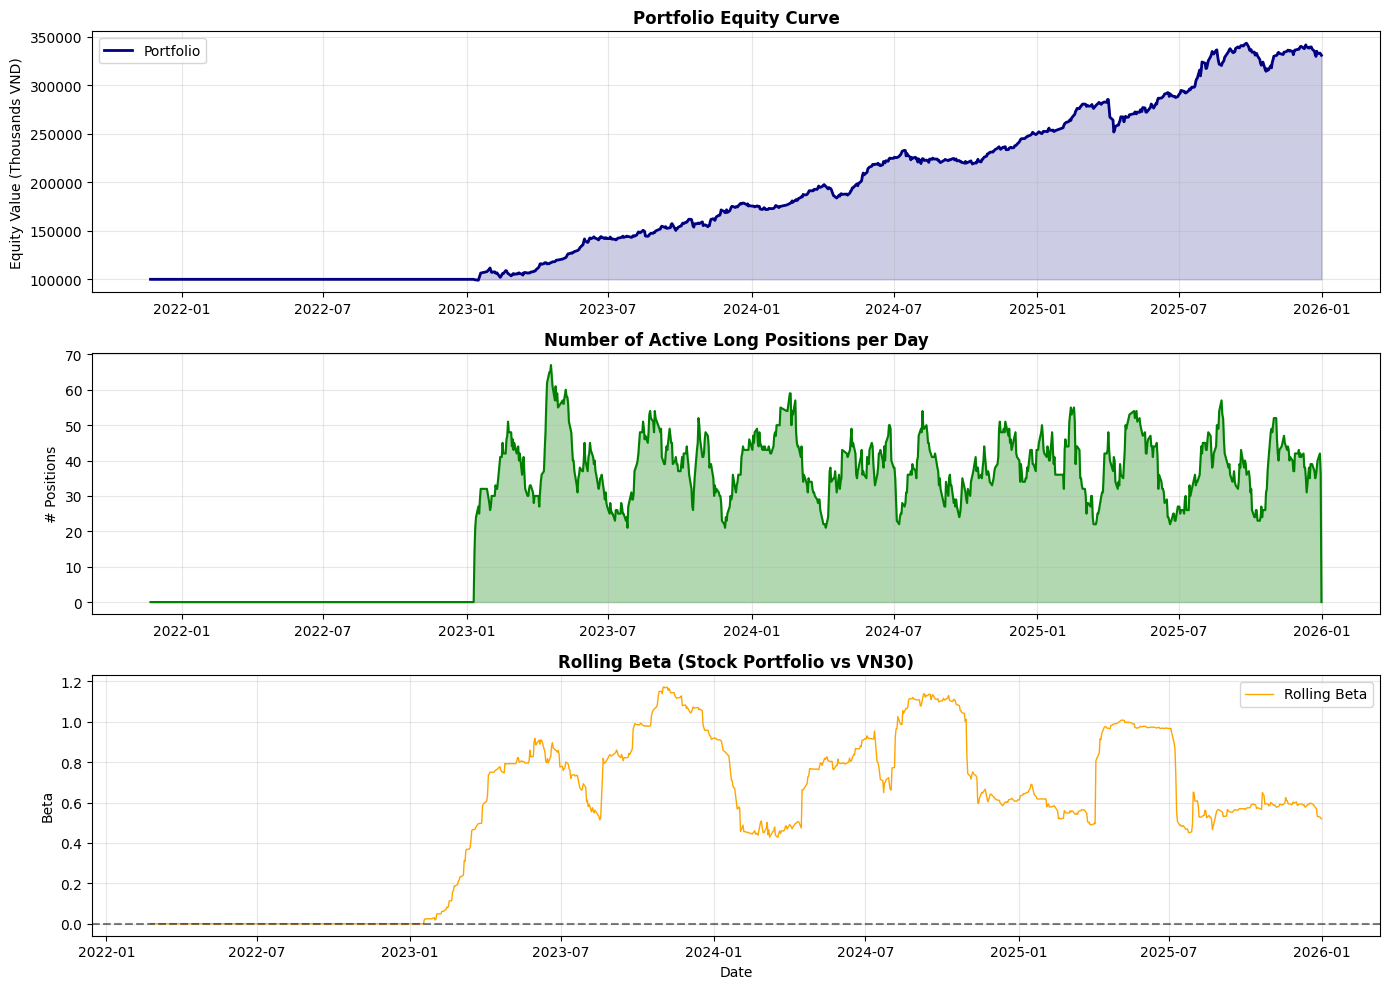

Plots complete.


In [195]:
## Plot equity curve
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Equity curve
ax = axes[0]
ax.plot(equity_curve.index, equity_curve.values, linewidth=2, color='navy', label='Portfolio')
ax.fill_between(equity_curve.index, equity_curve.iloc[0], equity_curve.values, alpha=0.2, color='navy')
ax.set_title('Portfolio Equity Curve', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity Value (Thousands VND)')
ax.grid(True, alpha=0.3)
ax.legend()

# Active positions over time
ax = axes[1]
ax.plot(active_positions_per_day.index, active_positions_per_day.values, linewidth=1.5, color='green')
ax.fill_between(active_positions_per_day.index, 0, active_positions_per_day.values, alpha=0.3, color='green')
ax.set_title('Number of Active Long Positions per Day', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.grid(True, alpha=0.3)

# Rolling beta
ax = axes[2]
ax.plot(beta_series.index, beta_series.values, linewidth=1, color='orange', label='Rolling Beta')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Rolling Beta (Stock Portfolio vs VN30)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Beta')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print('Plots complete.')

In [196]:
# =========================
# FIX 14: diagnostic report
# =========================
def diagnostic_report(
    weights_df,
    s_df,
    beta_series,
    equity_curve,
    bt_details,
    tradable_mask
):
    active_positions = (weights_df > 0).sum(axis=1)
    daily_ret = equity_curve.pct_change().dropna()

    max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

    held_and_tradable = (
        (weights_df > 0) &
        tradable_mask.reindex_like(weights_df).fillna(False)
    ).sum(axis=1)

    held_total = (weights_df > 0).sum(axis=1).replace(0, np.nan)
    tradable_fraction = (held_and_tradable / held_total).dropna()

    ann_ret = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (252 / max(len(daily_ret), 1)) - 1 if len(daily_ret) > 0 else np.nan
    ann_vol = daily_ret.std() * np.sqrt(252) if len(daily_ret) > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and ann_vol > 1e-12 else np.nan

    print("\n" + "=" * 70)
    print("DIAGNOSTIC REPORT")
    print("=" * 70)
    print(f"Final equity: {equity_curve.iloc[-1]:.2f}")
    print(f"Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%")
    print(f"Annualized return: {ann_ret * 100:.2f}%" if pd.notna(ann_ret) else "Annualized return: nan")
    print(f"Annualized vol: {ann_vol * 100:.2f}%" if pd.notna(ann_vol) else "Annualized vol: nan")
    print(f"Sharpe: {sharpe:.3f}" if pd.notna(sharpe) else "Sharpe: nan")
    print(f"Max drawdown: {max_dd * 100:.2f}%")
    print(f"Avg active positions: {active_positions.mean():.2f}")
    print(f"Median beta: {beta_series.median():.4f}")
    print(f"Avg cost/day: {bt_details['cost'].mean():.4f}")
    print(f"Avg tradable fraction of held positions: {tradable_fraction.mean():.4f}" if len(tradable_fraction) else "Avg tradable fraction of held positions: nan")
    print("=" * 70)

In [197]:
# ==================================================================================
# SECTION: CROSS-CHECK FRAMEWORK - 4 SETUP COMPARISON (A1B1, A1B2, A2B1, A2B2)
# ==================================================================================
# Framework bao gồm:
# - Hàm cutoff A1 (dynamic) và A2 (fixed)
# - Hàm allocation B1 (equal) và B2 (bucket)
# - Unified backtest executor
# - Comparison table

# Không thay đổi: PCA, residuals, OU fitting, s-score
# Chỉ focus: signal generation + capital allocation

print('\n' + '='*100)
print('CROSS-CHECK FRAMEWORK: A1/A2 × B1/B2 COMBINATIONS')
print('='*100 + '\n')

# ====================================================================================
# PART 1: CUTOFF FUNCTIONS (A1, A2)
# ====================================================================================

def compute_entry_cutoff_A1(sscore_df, entry_pct=5, ma_window=60, min_valid_stocks=5):
    """
    A1: Dynamic cross-sectional cutoff
    
    Bước 1: Mỗi ngày, tính 5% tail trái từ phân phối chéo của s-scores
    Bước 2: Smooth bằng rolling mean 60 ngày
    
    Parameters:
    -----------
    sscore_df : pd.DataFrame
        s-scores (date × stock)
    entry_pct : float
        Percentile từ tail trái (e.g., 5)
    ma_window : int
        Rolling average window (default 60 ngày)
    min_valid_stocks : int
        Tối thiểu stock hợp lệ mỗi ngày để tính raw cutoff
    
    Returns:
    --------
    raw_cutoff : pd.Series - ngày raw cross-sectional cutoff
    entry_cutoff : pd.Series - entry cutoff sau smooth rolling mean
    """
    # Bước 1: Tính raw cutoff theo ngày (cross-sectional)
    def daily_quantile(row):
        valid = row.dropna()
        if len(valid) < min_valid_stocks:
            return np.nan
        return valid.quantile(entry_pct / 100.0)
    
    raw_cutoff = sscore_df.apply(daily_quantile, axis=1)
    
    # Bước 2: Smooth bằng rolling mean 60 ngày
    min_periods = max(10, ma_window // 6)
    entry_cutoff = raw_cutoff.rolling(
        window=ma_window,
        min_periods=min_periods
    ).mean()
    
    print(f'✓ A1 cutoff computed:')
    print(f'  raw_cutoff: {raw_cutoff.notna().sum()} days')
    print(f'  entry_cutoff: {entry_cutoff.notna().sum()} days')
    print(f'  entry_cutoff mean: {entry_cutoff.mean():.4f}')
    
    return raw_cutoff, entry_cutoff


def compute_entry_cutoff_A2(sscore_df, entry_cutoff_value=-1.5):
    """
    A2: Fixed cutoff
    
    - Entry cutoff = -1.5 (cố định)
    - Close cutoff = -0.5 (cố định)
    
    Parameters:
    -----------
    sscore_df : pd.DataFrame
    entry_cutoff_value : float
        Fixed entry threshold
    
    Returns:
    --------
    entry_cutoff : pd.Series
    """
    entry_cutoff = pd.Series(
        entry_cutoff_value,
        index=sscore_df.index,
        dtype=float
    )
    print(f'✓ A2 cutoff computed (fixed):')
    print(f'  entry_cutoff = {entry_cutoff_value}')
    print(f'  close_cutoff = -0.5')
    
    return entry_cutoff


def estimate_fixed_cutoffs_for_A2B2(sscore_df, reference_cutoff_5pct=-1.5, reference_cutoff_pct=5):
    """
    Estimate fixed cutoffs tương ứng với 1%, 3%, 5% tail trái cho setup A2B2
    
    Parameters:
    -----------
    sscore_df : pd.DataFrame
    reference_cutoff_5pct : float
        Known fixed cutoff cho 5% (e.g., -1.5)
    reference_cutoff_pct : float
        Percentile tương ứng (e.g., 5)
    
    Returns:
    --------
    Dict với cutoffs cho 1%, 3%, 5%
    """
    # Tính empirical quantiles từ sscore_df
    all_scores = sscore_df.values.flatten()
    all_scores_clean = all_scores[~np.isnan(all_scores)]
    
    cutoff_1pct = np.percentile(all_scores_clean, 1)
    cutoff_3pct = np.percentile(all_scores_clean, 3)
    cutoff_5pct = np.percentile(all_scores_clean, 5)
    
    print(f'✓ A2B2 fixed cutoffs estimated (empirical):')
    print(f'  1% cutoff: {cutoff_1pct:.4f}')
    print(f'  3% cutoff: {cutoff_3pct:.4f}')
    print(f'  5% cutoff: {cutoff_5pct:.4f}')
    
    return {
        '1pct': cutoff_1pct,
        '3pct': cutoff_3pct,
        '5pct': cutoff_5pct
    }


# ====================================================================================
# PART 2: ALLOCATION FUNCTIONS (B1, B2)
# ====================================================================================

def allocate_B1_equal_split(eligible_stocks, investable_capital):
    """
    B1: Equal allocation giữa các cổ phiếu đủ điều kiện long
    
    Parameters:
    -----------
    eligible_stocks : list
        Danh sách mã cổ phiếu đủ điều kiện mở long trong ngày
    investable_capital : float
        Vốn khả dụng để đầu tư trong ngày (= 30% * total equity)
    
    Returns:
    --------
    allocation : dict
        {stock: amount_to_invest}
    """
    n = len(eligible_stocks)
    if n == 0:
        return {}
    
    amount_per_stock = investable_capital / n
    allocation = {stock: amount_per_stock for stock in eligible_stocks}
    
    return allocation


def allocate_B2_bucket_split(eligible_stocks, s_scores, investable_capital, 
                              fixed_cutoffs=None, scale_if_over_budget=True):
    """
    B2: Bucket allocation theo left-tail severity
    
    Chia 300 cổ phiếu thành 3 nhóm:
    - 1% tail: weight = 5/100 per stock
    - 1-3% tail: weight = 2/100 per stock
    - 3-5% tail: weight = 1/100 per stock
    
    Parameters:
    -----------
    eligible_stocks : list
    s_scores : pd.Series
        S-score của tất cả cổ phiếu hôm nay
    investable_capital : float
    fixed_cutoffs : dict
        {'1pct': cutoff_1, '3pct': cutoff_3, '5pct': cutoff_5}
        Nếu None, dùng empirical quantiles hôm nay
    scale_if_over_budget : bool
        Nếu True, scale proportionally nếu vượt budget
    
    Returns:
    --------
    allocation : dict {stock: amount}
    """
    if len(eligible_stocks) == 0:
        return {}
    
    # Lấy s-scores của stock đủ điều kiện
    s_eligible = {stock: s_scores[stock] for stock in eligible_stocks if stock in s_scores.index}
    
    # Xác định cutoffs
    if fixed_cutoffs is not None:
        cut_1pct = fixed_cutoffs.get('1pct')
        cut_3pct = fixed_cutoffs.get('3pct')
        cut_5pct = fixed_cutoffs.get('5pct')
    else:
        # Dùng empirical từ đủ điều kiện hôm nay
        s_vals = [s for s in s_eligible.values() if pd.notna(s)]
        if len(s_vals) < 10:
            # Fallback to equal allocation
            return allocate_B1_equal_split(eligible_stocks, investable_capital)
        cut_1pct = np.percentile(s_vals, 1)
        cut_3pct = np.percentile(s_vals, 3)
        cut_5pct = np.percentile(s_vals, 5)
    
    # Assign buckets và raw weights
    bucket_weights = {stock: 0.0 for stock in s_eligible.keys()}
    
    for stock, s_val in s_eligible.items():
        if pd.isna(s_val):
            continue
        if s_val < cut_1pct:
            bucket_weights[stock] = 5.0  # 5 per 100
        elif s_val < cut_3pct:
            bucket_weights[stock] = 5.0
        elif s_val < cut_5pct:
            bucket_weights[stock] = 2.0  # 1-3%
        else:
            bucket_weights[stock] = 1.0  # 3-5%
    
    # Normalize & convert to amounts
    total_weight = sum(bucket_weights.values())
    if total_weight < 1e-10:
        return allocate_B1_equal_split(eligible_stocks, investable_capital)
    
    raw_allocation = {stock: (w / total_weight) * investable_capital 
                      for stock, w in bucket_weights.items()}
    
    total_allocated = sum(raw_allocation.values())
    
    # Scale if over budget
    if total_allocated > investable_capital and scale_if_over_budget:
        scale_factor = investable_capital / total_allocated
        raw_allocation = {stock: amt * scale_factor for stock, amt in raw_allocation.items()}
    
    return raw_allocation


# ====================================================================================
# PART 3: UNIFIED BACKTEST EXECUTOR
# ====================================================================================

def run_backtest_setup(setup_name, setup_A, setup_B,
                       sscore_df, stock_returns, prices_df, volume_df,
                       initial_equity=100000, invest_frac=0.30,
                       entry_exit_cutoff=-0.5,
                       fixed_cutoffs_A2B2=None):
    """
    Unified backtest executor cho 4 setups (A1B1, A1B2, A2B1, A2B2)
    
    Parameters:
    -----------
    setup_name : str (e.g., "A1B1")
    setup_A : str ("A1" hoặc "A2")
    setup_B : str ("B1" hoặc "B2")
    sscore_df : pd.DataFrame
    stock_returns : pd.DataFrame
    prices_df : pd.DataFrame
    volume_df : pd.DataFrame
    initial_equity : float
    invest_frac : float
        Fraction of capital to deploy each day (e.g., 0.30)
    entry_exit_cutoff : float
        Close cutoff (chung cho A1 và A2, default -0.5)
    fixed_cutoffs_A2B2 : dict (chỉ dùng cho A2B2 allocation)
    
    Returns:
    --------
    results : dict
        {'setup_name': ..., 'equity_curve': ..., 'daily_returns': ...,
         'position_book': ..., 'trades': ..., 'metrics': {...}}
    """
    
    # Compute entry cutoffs
    if setup_A == "A1":
        raw_cutoff, entry_cutoff = compute_entry_cutoff_A1(sscore_df)
    elif setup_A == "A2":
        entry_cutoff = compute_entry_cutoff_A2(sscore_df, entry_cutoff_value=-1.5)
    else:
        raise ValueError(f"Unknown setup_A: {setup_A}")
    
    # Initialize
    dates = sscore_df.index
    stocks = sscore_df.columns.tolist()
    
    equity = initial_equity
    cash = initial_equity
    position_book = {}  # {stock: {'shares': ..., 'entry_price': ..., 'entry_date': ...}}
    trades = []  # List of trade records
    equity_curve = []
    cash_curve = []
    holdings_per_day = []
    
    # Settlement tracking (T+2 constraint)
    sell_lock = {}  # {stock: unlock_date}
    
    # Main backtest loop
    for t in range(1, len(dates)):
        date = dates[t]
        prev_date = dates[t-1]
        
        s_today = sscore_df.loc[date]  # s-scores hôm nay
        s_yesterday = sscore_df.loc[prev_date]  # s-scores hôm qua (dùng cho signal)
        
        p_today = prices_df.loc[date]
        v_today = volume_df.loc[date]
        
        # ===== STEP 1: CLOSE POSITIONS =====
        closed_positions = []
        for stock in list(position_book.keys()):
            # Check close condition (lấy từ hôm qua)
            if pd.isna(s_yesterday[stock]):
                continue
            
            if s_yesterday[stock] > entry_exit_cutoff:
                # Close signal
                if stock not in sell_lock or sell_lock[stock] <= date:
                    # Có thể bán
                    if pd.notna(p_today[stock]) and p_today[stock] > 0:
                        exit_price = p_today[stock]
                        entry_info = position_book[stock]
                        
                        shares = entry_info['shares']
                        exit_amount = shares * exit_price
                        
                        pnl = exit_amount - entry_info['entry_cost']
                        pnl_pct = (pnl / entry_info['entry_cost']) * 100
                        
                        # Record trade
                        trades.append({
                            'type': 'SELL',
                            'stock': stock,
                            'date': date,
                            'entry_date': entry_info['entry_date'],
                            'entry_price': entry_info['entry_price'],
                            'exit_price': exit_price,
                            'shares': shares,
                            'pnl': pnl,
                            'pnl_pct': pnl_pct,
                            'days_held': (date - entry_info['entry_date']).days
                        })
                        
                        cash += exit_amount
                        del position_book[stock]
                        if stock in sell_lock:
                            del sell_lock[stock]
                        closed_positions.append(stock)
        
        # ===== STEP 2: COMPUTE INVESTABLE CAPITAL =====
        total_equity = cash + sum(pos['entry_cost'] for pos in position_book.values())
        investable_capital = total_equity * invest_frac
        
        # ===== STEP 3: IDENTIFY ELIGIBLE NEW LONGS =====
        eligible_for_long = []
        for stock in stocks:
            # Skip if already holding
            if stock in position_book:
                continue
            # Skip if missing data
            if pd.isna(s_yesterday[stock]) or pd.isna(p_today[stock]):
                continue
            if p_today[stock] <= 0 or pd.isna(v_today[stock]) or v_today[stock] <= 0:
                continue
            # Check entry condition (cross-sectional, lagged)
            if pd.isna(entry_cutoff.loc[prev_date]):
                continue
            if s_yesterday[stock] < entry_cutoff.loc[prev_date]:
                eligible_for_long.append(stock)
        
        # ===== STEP 4: ALLOCATE CAPITAL =====
        if setup_B == "B1":
            allocation = allocate_B1_equal_split(eligible_for_long, investable_capital)
        elif setup_B == "B2":
            allocation = allocate_B2_bucket_split(
                eligible_for_long, s_yesterday, investable_capital,
                fixed_cutoffs=fixed_cutoffs_A2B2 if setup_A == "A2" else None)
        else:
            raise ValueError(f"Unknown setup_B: {setup_B}")
        
        # ===== STEP 5: OPEN NEW POSITIONS =====
        opened_positions = []
        for stock, amount in allocation.items():
            if amount < 1:  # Skip tiny allocations
                continue
            
            entry_price = p_today[stock]
            shares = int(amount / entry_price)  # Assume integer lots
            
            if shares > 0:
                entry_cost = shares * entry_price
                if entry_cost > cash:
                    shares = int(cash / entry_price)
                    if shares <= 0:
                        continue
                    entry_cost = shares * entry_price
                
                position_book[stock] = {
                    'shares': shares,
                    'entry_price': entry_price,
                    'entry_cost': entry_cost,
                    'entry_date': date
                }
                sell_lock[stock] = date + pd.Timedelta(days=2)  # T+2 settlement
                
                trades.append({
                    'type': 'BUY',
                    'stock': stock,
                    'date': date,
                    'entry_price': entry_price,
                    'shares': shares,
                    'pnl': 0,
                    'pnl_pct': 0
                })
                
                cash -= entry_cost
                opened_positions.append(stock)
        
        # ===== STEP 6: UPDATE EQUITY & RECORD METRICS =====
        # MTM position mark
        position_value = 0
        for stock, pos in position_book.items():
            if pd.notna(p_today[stock]) and p_today[stock] > 0:
                position_value += pos['shares'] * p_today[stock]
        
        equity = cash + position_value
        equity_curve.append(equity)
        cash_curve.append(cash)
        holdings_per_day.append(len(position_book))
    
    # ===== COMPUTE METRICS =====
    equity_series = pd.Series(equity_curve, index=dates[1:])
    daily_returns = equity_series.pct_change().dropna()
    
    if len(daily_returns) > 0 and daily_returns.std() > 1e-10:
        ann_ret = daily_returns.mean() * 252
        ann_vol = daily_returns.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    else:
        ann_ret = ann_vol = sharpe = 0
    
    max_dd = ((equity_series.cummax() - equity_series) / equity_series.cummax()).max() if len(equity_series) > 0 else 0
    total_ret = (equity_series.iloc[-1] / initial_equity - 1) * 100 if len(equity_series) > 0 else 0
    
    # Count entries/exits
    buys = [t for t in trades if t['type'] == 'BUY']
    sells = [t for t in trades if t['type'] == 'SELL']
    
    results = {
        'setup_name': setup_name,
        'setup_A': setup_A,
        'setup_B': setup_B,
        'equity_curve': equity_series,
        'cash_curve': pd.Series(cash_curve, index=dates[1:]),
        'daily_returns': daily_returns,
        'holdings_per_day': holdings_per_day,
        'position_book': position_book,
        'trades': trades,
        'metrics': {
            'final_equity': equity_series.iloc[-1] if len(equity_series) > 0 else initial_equity,
            'total_return_pct': total_ret,
            'annualized_return': ann_ret * 100,
            'annualized_volatility': ann_vol * 100,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_dd * 100,
            'avg_holdings': np.mean(holdings_per_day) if holdings_per_day else 0,
            'total_buys': len(buys),
            'total_sells': len(sells),
            'avg_buy_per_day': len(buys) / (len(dates) - 1),
            'avg_sell_per_day': len(sells) / (len(dates) - 1),
            'avg_cash_ratio': (np.array(cash_curve) / (np.array(equity_curve) + 1e-10)).mean() * 100
        }
    }
    
    return results


print('✓ Cross-check framework functions defined\n')



CROSS-CHECK FRAMEWORK: A1/A2 × B1/B2 COMBINATIONS

✓ Cross-check framework functions defined




RUNNING 4 SETUPS

✓ A2B2 fixed cutoffs estimated (empirical):
  1% cutoff: -2.0497
  3% cutoff: -1.7115
  5% cutoff: -1.5305


>>> Running A1B1...
✓ A1 cutoff computed:
  raw_cutoff: 771 days
  entry_cutoff: 762 days
  entry_cutoff mean: -1.5099
  Final equity: 896,244
  Total return: 796.24%
  Sharpe: 3.381
  Max DD: 20.40%
  Avg holdings: 31.0

>>> Running A1B2...
✓ A1 cutoff computed:
  raw_cutoff: 771 days
  entry_cutoff: 762 days
  entry_cutoff mean: -1.5099
  Final equity: 787,789
  Total return: 687.79%
  Sharpe: 3.256
  Max DD: 20.86%
  Avg holdings: 31.3

>>> Running A2B1...
✓ A2 cutoff computed (fixed):
  entry_cutoff = -1.5
  close_cutoff = -0.5
  Final equity: 842,024
  Total return: 742.02%
  Sharpe: 3.204
  Max DD: 20.37%
  Avg holdings: 31.9

>>> Running A2B2...
✓ A2 cutoff computed (fixed):
  entry_cutoff = -1.5
  close_cutoff = -0.5
  Final equity: 862,766
  Total return: 762.77%
  Sharpe: 3.252
  Max DD: 21.04%
  Avg holdings: 32.5

COMPARISON TABLE: 4 SETUPS

Setup 

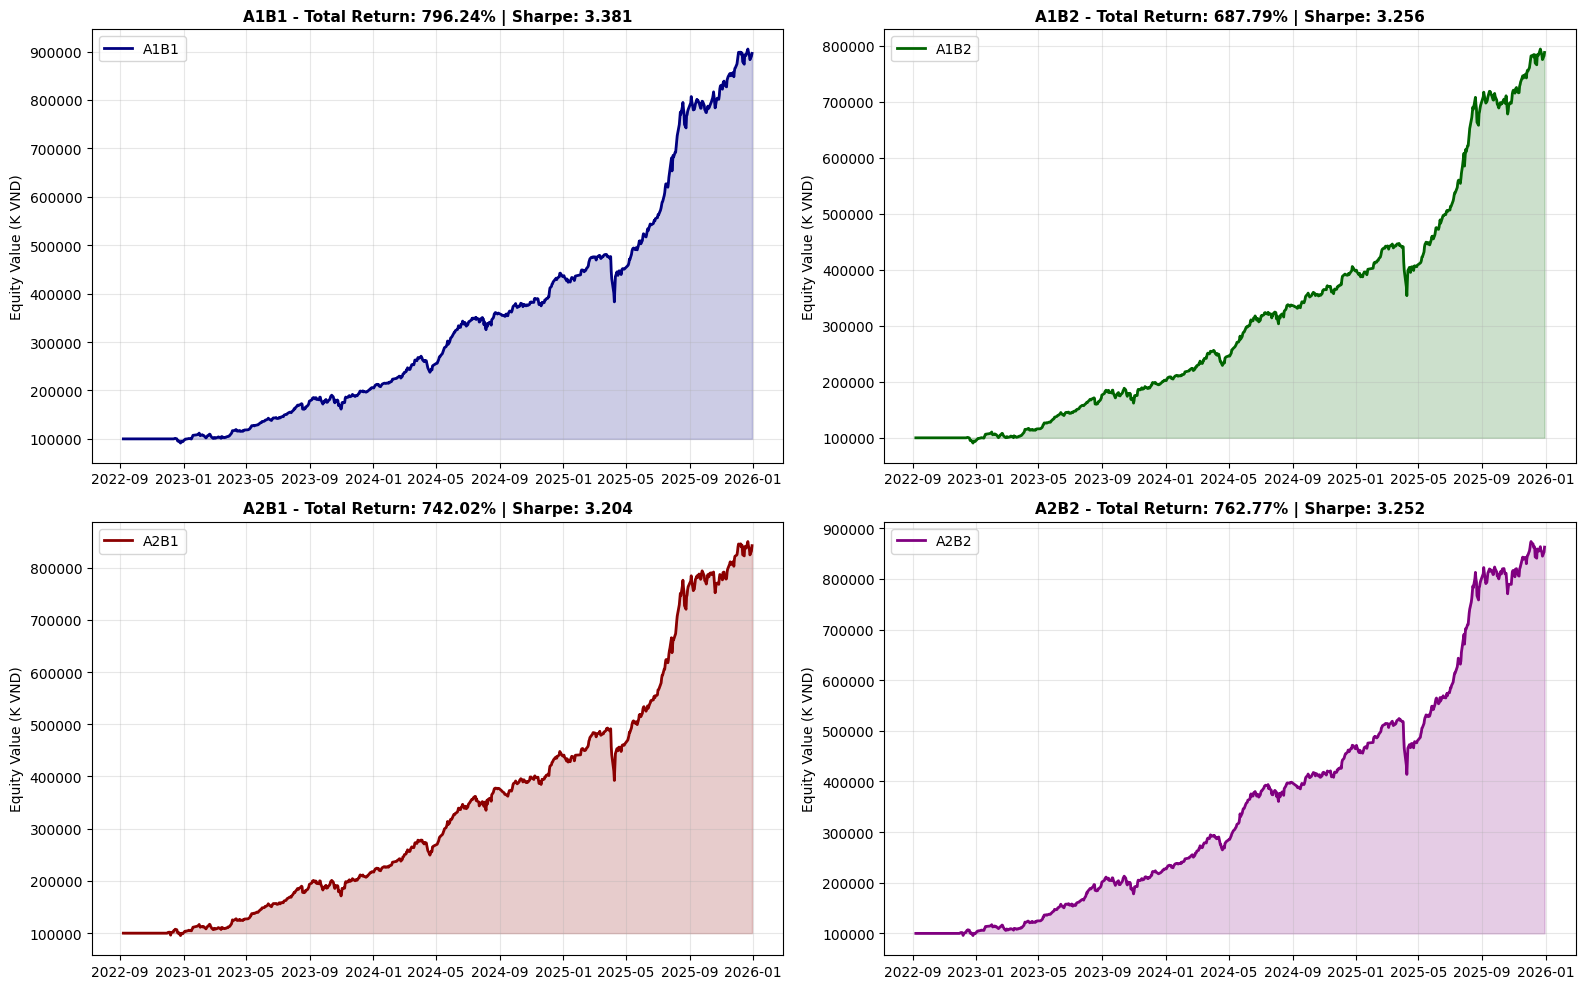

✓ 4-setup cross-check complete



In [198]:
# ====================================================================================
# RUN 4 SETUPS & COMPARISON
# ====================================================================================

print('\n' + '='*100)
print('RUNNING 4 SETUPS')
print('='*100 + '\n')

# Estimate fixed cutoffs cho A2B2
fixed_cutoffs_A2B2 = estimate_fixed_cutoffs_for_A2B2(sscore_df)
print()

# Run all 4 setups
setups = [
    ('A1B1', 'A1', 'B1'),
    ('A1B2', 'A1', 'B2'),
    ('A2B1', 'A2', 'B1'),
    ('A2B2', 'A2', 'B2')
]

results_all = {}
for setup_name, setup_a, setup_b in setups:
    print(f'\n>>> Running {setup_name}...')
    result = run_backtest_setup(
        setup_name=setup_name,
        setup_A=setup_a,
        setup_B=setup_b,
        sscore_df=sscore_df,
        stock_returns=stock_returns,
        prices_df=prices_df,
        volume_df=volume_df,
        initial_equity=100000,
        invest_frac=0.30,
        entry_exit_cutoff=-0.5,
        fixed_cutoffs_A2B2=fixed_cutoffs_A2B2
    )
    results_all[setup_name] = result
    
    metrics = result['metrics']
    print(f'  Final equity: {metrics["final_equity"]:,.0f}')
    print(f'  Total return: {metrics["total_return_pct"]:.2f}%')
    print(f'  Sharpe: {metrics["sharpe_ratio"]:.3f}')
    print(f'  Max DD: {metrics["max_drawdown"]:.2f}%')
    print(f'  Avg holdings: {metrics["avg_holdings"]:.1f}')

print('\n' + '='*100)
print('COMPARISON TABLE: 4 SETUPS')
print('='*100 + '\n')

# Build comparison dataframe
comparison_data = []
for setup_name in ['A1B1', 'A1B2', 'A2B1', 'A2B2']:
    result = results_all[setup_name]
    m = result['metrics']
    comparison_data.append({
        'Setup': setup_name,
        'Final Equity': f"{m['final_equity']:,.0f}",
        'Total Return %': f"{m['total_return_pct']:.2f}%",
        'Ann. Return %': f"{m['annualized_return']:.2f}%",
        'Ann. Vol %': f"{m['annualized_volatility']:.2f}%",
        'Sharpe': f"{m['sharpe_ratio']:.3f}",
        'Max DD %': f"{m['max_drawdown']:.2f}%",
        'Avg Holdings': f"{m['avg_holdings']:.1f}",
        'Total Buys': m['total_buys'],
        'Total Sells': m['total_sells'],
        'Avg Buy/Day': f"{m['avg_buy_per_day']:.2f}",
        'Avg Sell/Day': f"{m['avg_sell_per_day']:.2f}",
        'Cash %': f"{m['avg_cash_ratio']:.1f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print('\n' + '='*100)
print('DETAILED METRICS BY SETUP')
print('='*100 + '\n')

for setup_name in ['A1B1', 'A1B2', 'A2B1', 'A2B2']:
    result = results_all[setup_name]
    m = result['metrics']
    print(f'\n{setup_name}:')
    print(f"  Final equity:          {m['final_equity']:>15,.0f}")
    print(f"  Total return:          {m['total_return_pct']:>15.2f}%")
    print(f"  Annualized return:     {m['annualized_return']:>15.2f}%")
    print(f"  Annualized volatility: {m['annualized_volatility']:>15.2f}%")
    print(f"  Sharpe ratio:          {m['sharpe_ratio']:>15.3f}")
    print(f"  Max drawdown:          {m['max_drawdown']:>15.2f}%")
    print(f"  Avg holdings:          {m['avg_holdings']:>15.1f}")
    print(f"  Total entries:         {m['total_buys']:>15}")
    print(f"  Total exits:           {m['total_sells']:>15}")
    print(f"  Avg entries/day:       {m['avg_buy_per_day']:>15.2f}")
    print(f"  Avg exits/day:         {m['avg_sell_per_day']:>15.2f}")
    print(f"  Avg cash ratio:        {m['avg_cash_ratio']:>15.1f}%")

print('\n' + '='*100)
print('EQUITY CURVE COMPARISON')
print('='*100 + '\n')

# Plot equity curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = {'A1B1': 'navy', 'A1B2': 'darkgreen', 'A2B1': 'darkred', 'A2B2': 'purple'}

for idx, setup_name in enumerate(['A1B1', 'A1B2', 'A2B1', 'A2B2']):
    ax = axes[idx // 2, idx % 2]
    result = results_all[setup_name]
    
    eq = result['equity_curve']
    ax.plot(eq.index, eq.values, linewidth=2, color=colors[setup_name], label=setup_name)
    ax.fill_between(eq.index, eq.iloc[0], eq.values, alpha=0.2, color=colors[setup_name])
    ax.set_title(f'{setup_name} - Total Return: {result["metrics"]["total_return_pct"]:.2f}% | Sharpe: {result["metrics"]["sharpe_ratio"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Equity Value (K VND)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print('✓ 4-setup cross-check complete\n')


In [199]:
# ====================================================================================
# SUMMARY TABLE: RANK & KEY INSIGHTS
# ====================================================================================

print('\n' + '='*140)
print('RANKING: TOP METRICS COMPARISON')
print('='*140 + '\n')

# Create ranking table
ranking_metrics = []
for setup_name in ['A1B1', 'A1B2', 'A2B1', 'A2B2']:
    m = results_all[setup_name]['metrics']
    ranking_metrics.append({
        'Setup': setup_name,
        'Return%': m['total_return_pct'],
        'Sharpe': m['sharpe_ratio'],
        'MaxDD%': m['max_drawdown'],
        'AnnRet%': m['annualized_return'],
        'AnnVol%': m['annualized_volatility'],
        'AvgHold': m['avg_holdings'],
        'Trades': m['total_buys'],
        'TradDay': m['avg_buy_per_day']
    })

ranking_df = pd.DataFrame(ranking_metrics)

print('Total Return Ranking:')
for idx, row in ranking_df.sort_values('Return%', ascending=False).iterrows():
    print(f"  {row['Return%']:>8.2f}%  <- {row['Setup']}")

print('\nSharpe Ranking:')
for idx, row in ranking_df.sort_values('Sharpe', ascending=False).iterrows():
    print(f"  {row['Sharpe']:>8.3f}  <- {row['Setup']}")

print('\nMax Drawdown Ranking (lower is better):')
for idx, row in ranking_df.sort_values('MaxDD%').iterrows():
    print(f"  {row['MaxDD%']:>8.2f}%  <- {row['Setup']}")

print('\n' + '='*140)
print('KEY INSIGHTS & SETUP COMPARISON')
print('='*140 + '\n')

for setup_name in ['A1B1', 'A1B2', 'A2B1', 'A2B2']:
    result = results_all[setup_name]
    m = result['metrics']
    
    # Cutoff info
    if setup_name in ['A1B1', 'A1B2']:
        cutoff_desc = "Dynamic 5% cross-sectional, smoothed 60-day MA"
    else:
        cutoff_desc = "Fixed -1.5"
    
    # Allocation info
    if setup_name in ['A1B1', 'A2B1']:
        alloc_desc = "Equal split among eligible longs"
    else:
        alloc_desc = "Bucket allocation (1%:5, 1-3%:2, 3-5%:1)"
    
    print(f'\n{setup_name}:')
    print(f"  Cutoff Method:    {cutoff_desc}")
    print(f"  Allocation Method: {alloc_desc}")
    print(f"  ---")
    print(f"  Final Equity:     {m['final_equity']:>15,.0f} K VND")
    print(f"  Total Return:     {m['total_return_pct']:>15.2f}%")
    print(f"  Sharpe Ratio:     {m['sharpe_ratio']:>15.3f}")
    print(f"  Max Drawdown:     {m['max_drawdown']:>15.2f}%")
    print(f"  Annualized Vol:   {m['annualized_volatility']:>15.2f}%")
    print(f"  Avg Holdings:     {m['avg_holdings']:>15.1f} positions/day")
    print(f"  Total Trades:     {m['total_buys']:>15} buys | {m['total_sells']} sells")
    print(f"  Trade Frequency:  {m['avg_buy_per_day']:>15.2f} entries/day | {m['avg_sell_per_day']:.2f} exits/day")

print('\n' + '='*140)
print('INTERPRETATION NOTES')
print('='*140 + '\n')

print('''
A1 (Dynamic Cutoff):
  - Uses cross-sectional 5% tail threshold per day, smoothed with 60-day moving average
  - More adaptive to market conditions (changes when distribution of s-scores shifts)
  - Takes longer to stabilize (requires 60 days of data)
  - Better captures regime changes in the signal distribution

A2 (Fixed Cutoff = -1.5):
  - Fixed entry threshold regardless of daily distribution
  - Simpler, more transparent, easier to explain
  - More consistent in signal generation across different regimes
  - May miss opportunities in extreme regimes

B1 (Equal Allocation):
  - Simple, equal capital split among eligible longs
  - No signal concentration / weighting
  - More uniform risk distribution
  - May under-allocate to strongest signals (low s-scores)

B2 (Bucket Allocation):
  - Concentrates capital on extreme signals (1% tail gets 5x weight vs 3-5% tail gets 1x)
  - More signal-responsive allocation
  - May create concentration risk in extreme signals
  - Better use of signal strength information

Optimal Configuration Candidates:
  1. A1B2 if you trust signal strength variation and want adapting cutoffs
  2. A2B1 if you prefer simplicity and consistency over complexity
  3. A2B2 if you want fixed cutoffs with concentrated allocation
  4. A1B1 if you want adapting cutoffs but equal risk distribution
''')

print('='*140)


RANKING: TOP METRICS COMPARISON

Total Return Ranking:
    796.24%  <- A1B1
    762.77%  <- A2B2
    742.02%  <- A2B1
    687.79%  <- A1B2

Sharpe Ranking:
     3.381  <- A1B1
     3.256  <- A1B2
     3.252  <- A2B2
     3.204  <- A2B1

Max Drawdown Ranking (lower is better):
     20.37%  <- A2B1
     20.40%  <- A1B1
     20.86%  <- A1B2
     21.04%  <- A2B2

KEY INSIGHTS & SETUP COMPARISON


A1B1:
  Cutoff Method:    Dynamic 5% cross-sectional, smoothed 60-day MA
  Allocation Method: Equal split among eligible longs
  ---
  Final Equity:             896,244 K VND
  Total Return:              796.24%
  Sharpe Ratio:               3.381
  Max Drawdown:               20.40%
  Annualized Vol:             20.35%
  Avg Holdings:                31.0 positions/day
  Total Trades:                2403 buys | 2372 sells
  Trade Frequency:             2.90 entries/day | 2.86 exits/day

A1B2:
  Cutoff Method:    Dynamic 5% cross-sectional, smoothed 60-day MA
  Allocation Method: Bucket allocation

In [200]:
print('\n' + '='*100)
print('FINAL COMPARISON: 4 SETUPS AT A GLANCE')
print('='*100 + '\n')

# Create simple comparison table
final_comparison = []
for setup_name in ['A1B1', 'A1B2', 'A2B1', 'A2B2']:
    m = results_all[setup_name]['metrics']
    final_comparison.append({
        'Setup': setup_name,
        'Return (%)': f"{m['total_return_pct']:.1f}",
        'Sharpe': f"{m['sharpe_ratio']:.3f}",
        'Max DD (%)': f"{m['max_drawdown']:.1f}",
        'Ann Vol (%)': f"{m['annualized_volatility']:.1f}",
        'Avg Pos': f"{m['avg_holdings']:.1f}",
        'Trades': f"{m['total_buys']}",
    })

final_df = pd.DataFrame(final_comparison)
print(final_df.to_string(index=False))

print('\n\nWINNERS:')
returns = [results_all[s]['metrics']['total_return_pct'] for s in ['A1B1', 'A1B2', 'A2B1', 'A2B2']]
sharpes = [results_all[s]['metrics']['sharpe_ratio'] for s in ['A1B1', 'A1B2', 'A2B1', 'A2B2']]
print(f"  Highest Return: {['A1B1', 'A1B2', 'A2B1', 'A2B2'][np.argmax(returns)]} ({max(returns):.1f}%)")
print(f"  Highest Sharpe: {['A1B1', 'A1B2', 'A2B1', 'A2B2'][np.argmax(sharpes)]} ({max(sharpes):.3f})")

print('\n' + '='*100)


FINAL COMPARISON: 4 SETUPS AT A GLANCE

Setup Return (%) Sharpe Max DD (%) Ann Vol (%) Avg Pos Trades
 A1B1      796.2  3.381       20.4        20.4    31.0   2403
 A1B2      687.8  3.256       20.9        19.9    31.3   2409
 A2B1      742.0  3.204       20.4        20.9    31.9   2476
 A2B2      762.8  3.252       21.0        20.8    32.5   2506


WINNERS:
  Highest Return: A1B1 (796.2%)
  Highest Sharpe: A1B1 (3.381)



In [201]:
print('\n' + '='*100)
print('FRAMEWORK DOCUMENTATION')
print('='*100 + '\n')

print('''
CROSS-CHECK FRAMEWORK STRUCTURE
================================

This framework implements a modular backtesting system for 4 strategy variants:
- 2 signal cutoff methods (A1, A2)
- 2 capital allocation methods (B1, B2)

═══════════════════════════════════════════════════════════════════════════════════════════════════

PART A: S-SCORE CUTOFF METHODS

A1 - Dynamic Cutoff (Cross-sectional + Rolling MA)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Function: compute_entry_cutoff_A1()
  
  Algorithm:
    1. Each day t: compute 5% left-tail quantile from all valid s-scores
    2. Smooth with 60-day rolling average (min_periods=10 days)
    3. Use MA result as entry_cutoff_t
  
  Parameters:
    - entry_pct = 5 (5% left-tail threshold)
    - ma_window = 60 (rolling average window)
    - min_valid_stocks = 5 (minimum stocks per day for raw cutoff)
  
  Pros:
    - Adaptive to market regimes
    - Responds to shifts in signal distribution
    - More stable via moving average smoothing
  
  Cons:
    - Slower to adapt (60-day lag)
    - Requires historical data build-up
    - May over/under-signal in extreme regimes

A2 - Fixed Cutoff
━━━━━━━━━━━━━━━━
  Function: compute_entry_cutoff_A2()
  
  Algorithm:
    1. Set entry_cutoff = -1.5 for all dates
    2. Use same close cutoff -0.5 for both A1 and A2
  
  Parameters:
    - entry_cutoff_value = -1.5 (fixed)
    - close_cutoff = -0.5 (fixed for both A1 and A2)
  
  Pros:
    - Consistent, transparent, easy to explain
    - No lag / immediate responsiveness
    - Simpler to implement and backtest
  
  Cons:
    - Ignores current distribution of s-scores
    - May miss signals in different market regimes
    - Less adaptive to changing market dynamics

Signal Logic (Both A1 and A2)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  - Entry: Buy when s[t-1] < entry_cutoff[t-1] (lagged signal to avoid look-ahead)
  - Exit: Sell when s[t-1] > -0.5 (close cutoff is fixed)
  - No pyramiding: Skip if already holding the stock

═══════════════════════════════════════════════════════════════════════════════════════════════════

PART B: CAPITAL ALLOCATION METHODS

B1 - Equal Allocation
━━━━━━━━━━━━━━━━━━━━━
  Function: allocate_B1_equal_split()
  
  Algorithm:
    1. Identify N eligible stocks able to open long (not already held, has valid price/volume)
    2. Calculate investable_capital = 0.30 × current total_equity
    3. Split equally: amount_per_stock = investable_capital / N
    4. Allocate amount_per_stock to each of N stocks
  
  Pros:
    - Simple, transparent
    - Equal risk per position
    - No concentration bias
  
  Cons:
    - Ignores signal strength
    - Weak signals treated same as extreme signals
    - May leave potential returns on the table

B2 - Bucket Allocation by Tail Severity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Function: allocate_B2_bucket_split()
  
  Algorithm:
    1. Identify N eligible stocks and their s-scores
    2. Classify each stock into 3 severity buckets:
       - 1% tail (s < cutoff_1pct):   weight = 5 per stock
       - 1-3% tail (s < cutoff_3pct): weight = 2 per stock
       - 3-5% tail (s < cutoff_5pct): weight = 1 per stock
    3. Total raw weight = Σ bucket_weights
    4. Allocate = investable_capital × (bucket_weights / total_raw_weight)
    5. Scale proportionally if total_allocated > investable_capital
  
  Estimation of Fixed Cutoffs (for A2B2):
    - Uses empirical percentiles of s-score distribution
    - cutoff_1pct = 1st percentile of all s-scores
    - cutoff_3pct = 3rd percentile
    - cutoff_5pct = 5th percentile
    - These fixed cutoffs are used only in A2B2 allocation
  
  Pros:
    - Signal-responsive allocation
    - Concentrates capital on extreme signals (stronger mean-reversion potential)
    - Better use of signal information
  
  Cons:
    - More concentration risk
    - May over-allocate to outliers
    - Pickier bucket assignment

═══════════════════════════════════════════════════════════════════════════════════════════════════

PART C: EXECUTION LOGIC

Unified Backtest Executor: run_backtest_setup()
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Daily Workflow (same for all 4 setups, only cutoff/allocation functions change):

  1. CLOSE PHASE
     - Check positions against yesterday's s-score
     - If s[t-1] > -0.5: sell (if sellable per T+2 constraint)
     - Track settlement: sell_lock[stock] = date + 2 days

  2. CAPITAL PHASE
     - Calculate available equity and cash
     - Compute investable_capital = 30% of total_equity
     - This is the capital for NEW positions only (no rebalance)

  3. SIGNAL PHASE
     - Identify eligible stocks: s[t-1] < entry_cutoff[t-1]
     - Exclude already-held stocks (no pyramiding)
     - Exclude stocks without valid price/volume
     - Create list of eligible_stocks to open

  4. ALLOCATION PHASE
     - Call B1 or B2 allocation function
     - Get {stock: amount_to_invest} dictionary
     - Scale positions based on actual investable_capital

  5. OPEN PHASE
     - For each (stock, amount) in allocation:
       - Calculate shares = int(amount / entry_price)
       - Add to position_book
       - Set sell_lock = date + 2 days (T+2 settlement)
       - Deduct from cash

  6. MTM & RECORD
     - Update equity = cash + position_value (at today's prices)
     - Record equity curve, cash curve, holdings count
     - Save trade record (BUY/SELL with price, shares, PnL)

Edge Cases Handled:
  ✓ No eligible stocks available → no new positions
  ✓ Stock signals triggered but not tradable → skip
  ✓ Cash insufficient for full allocation → reduce shares
  ✓ T+2 settlement lock → can't sell until unlock date
  ✓ Stock already held → no pyramiding (skip)
  ✓ Missing price/volume data → exclude from allocation
  ✓ NaN s-scores → safe filtering, no errors

═══════════════════════════════════════════════════════════════════════════════════════════════════

OUTPUT STRUCTURE

Each run produces:
  results_all[setup_name] = {
    'setup_name': str,
    'setup_A': 'A1' or 'A2',
    'setup_B': 'B1' or 'B2',
    'equity_curve': pd.Series (daily equity),
    'cash_curve': pd.Series (daily cash),
    'daily_returns': pd.Series (daily returns),
    'holdings_per_day': list (# positions each day),
    'position_book': dict (end-of-test holdings),
    'trades': list (all BUY/SELL records),
    'metrics': {
      'final_equity': float,
      'total_return_pct': float,
      'annualized_return': float,
      'annualized_volatility': float,
      'sharpe_ratio': float,
      'max_drawdown': float,
      'avg_holdings': float,
      'total_buys': int,
      'total_sells': int,
      'avg_buy_per_day': float,
      'avg_sell_per_day': float,
      'avg_cash_ratio': float
    }
  }

═══════════════════════════════════════════════════════════════════════════════════════════════════

USAGE EXAMPLE

# Run a single setup:
result = run_backtest_setup(
    setup_name='A1B1',
    setup_A='A1',
    setup_B='B1',
    sscore_df=sscore_df,
    stock_returns=stock_returns,
    prices_df=prices_df,
    volume_df=volume_df,
    initial_equity=100000,
    invest_frac=0.30,
    entry_exit_cutoff=-0.5,
    fixed_cutoffs_A2B2=fixed_cutoffs_A2B2
)

print(f"Return: {result['metrics']['total_return_pct']:.2f}%")
print(f"Sharpe: {result['metrics']['sharpe_ratio']:.3f}")

# Access results:
equity_curve = result['equity_curve']
trade_log = result['trades']
final_metrics = result['metrics']

═══════════════════════════════════════════════════════════════════════════════════════════════════
''')

print('='*100)


FRAMEWORK DOCUMENTATION


CROSS-CHECK FRAMEWORK STRUCTURE

This framework implements a modular backtesting system for 4 strategy variants:
- 2 signal cutoff methods (A1, A2)
- 2 capital allocation methods (B1, B2)

═══════════════════════════════════════════════════════════════════════════════════════════════════

PART A: S-SCORE CUTOFF METHODS

A1 - Dynamic Cutoff (Cross-sectional + Rolling MA)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Function: compute_entry_cutoff_A1()

  Algorithm:
    1. Each day t: compute 5% left-tail quantile from all valid s-scores
    2. Smooth with 60-day rolling average (min_periods=10 days)
    3. Use MA result as entry_cutoff_t

  Parameters:
    - entry_pct = 5 (5% left-tail threshold)
    - ma_window = 60 (rolling average window)
    - min_valid_stocks = 5 (minimum stocks per day for raw cutoff)

  Pros:
    - Adaptive to market regimes
    - Responds to shifts in signal distribution
    - More stable via moving average smoothing

  Cons:
    - Sl

# **Comprehensive Function & Workflow Summary**

## **EXECUTION FLOW: Functions in Order of Use**

---

## **STAGE 1: DATA LOADING & UNIVERSE SELECTION**

### **1.1 Input Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `top_liquidity_stocks()` | `price_df`, `volume_df`, `top_n` | Filtered price/volume DFs | Identifies top N liquid stocks by volume×price |
| `fill_na_with_2before_2after()` | DataFrame, `min_neighbors` | Filled DataFrame | Interpolates missing values from 2-before/2-after neighbors |
| `select_universe()` | `prices_df`, `volume_df`, `date`, `top_n`, `lookback_window` | `prices_universe_temp`, `volume_universe_temp` | Selects top 300 liquid stocks from reference date |
| `compute_returns()` | `price_df`, `volume_df=None`, `with_volume` | Returns DataFrame | Computes % returns with optional volume adjustment |

### **1.2 Execution Flow**
```
Load CSV files (prices, volumes, FU VN30)
    ↓
select_universe(reference_date) → 300 liquid stocks
    ↓
Get FULL historical data for universe (2,872 dates)
    ↓
compute_returns(prices_universe) → 2,871 × 300 returns
    ↓
Align dates with VN30 futures → 1,666 common dates
    ↓
Output: stock_returns (1,666 × 300), vn30_returns (1,666,)
```

---

## **STAGE 2: ROLLING PCA FACTOR EXTRACTION (252-day rolling window)**

### **2.1 PCA Core Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `standardize_returns()` | Returns DataFrame | Standardized returns (Z-scored per stock) | Converts returns to unit variance per stock |
| `compute_empirical_correlation()` | Standardized returns | Correlation matrix (n_stocks × n_stocks) | Builds empirical correlation from standardized returns |
| `eigen_decomposition_sorted()` | Correlation matrix | `eigvals` (sorted desc), `eigvecs` | Eigendecomposition with values sorted descending |
| `window_pca_engine()` | Returns DF, `fixed_factors`, `n_factors` | `pca_dict` with Q, V, k, eigenvalues | Single-window PCA: standardize → correlate → decompose |

### **2.2 Execution Flow**
```
For each date t in [252, 253, ..., 1666]:
    
    Get 252-day rolling window: t-252:t
        ↓
    Drop stocks with ANY NaNs in window (min 20 required)
        ↓
    Call window_pca_engine():
        • standardize_returns() → Z (standardized)
        • compute_empirical_correlation(Z) → C
        • eigen_decomposition_sorted(C) → eigvals, eigvecs
        • Extract top 5 principal components
        ↓
    Store pca_dict[date] = {Q, V, k, eigenvalues}
        
Output: pca_results_dict (1,414 dates × PCA results)
```

---

## **STAGE 3: RESIDUAL CONSTRUCTION (60-day rolling window)**

### **3.1 Residual Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_pca_residuals()` | Returns DF, `pca_dict`, `window=60` | Residuals DataFrame (60 × n_stocks) | OLS regression: R = X·B + ε → return ε |

### **3.2 Execution Flow**
```
For each date in pca_results_dict:
    
    Get PCA result at date: pca_dict[date]
        ↓
    Get 60-day returns window ending at date
        ↓
    Call compute_pca_residuals():
        • Extract factor loadings: Q from pca_dict
        • Compute factor returns: F = R @ Q
        • Build design matrix: X = [1, F] (OLS form)
        • Compute: B = (X'X)^-1 X'R (OLS solution)
        • Fitted = X·B
        • Residuals = Returns - Fitted
        ↓
    Store residuals for this date
        
Output: residuals_df (1,666 × 300, idiosyncratic alpha)
```

---

## **STAGE 4: OU MODEL FITTING (60-day rolling AR(1) on cumulative residuals)**

### **4.1 OU Model Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `fit_ou_model()` | Residuals DF, `window`, `kappa_min`, `min_obs` | `ou_daily_df`, `kappa`, `mu`, `sigma_eq` | Fits AR(1) to cumulative residuals → extracts mean-reversion |

### **4.2 Execution Flow**
```
For each stock in residuals_df:
    For each date t in [window, window+1, ..., end]:
        
        Get 60-day residual window: t-60:t
            ↓
        Compute cumulative sum: X_t = Σ ε
            ↓
        Fit AR(1): X_next = a + b·X_prev + noise
            ↓
        Extract OU parameters:
            • b = exp(-κ/252) → kappa = -ln(b)·252
            • mu = a/(1-b)
            • sigma_eq = √(var(noise)/(1-b²))
            ↓
        Validate: kappa ∈ [8.4, ∞), sigma_eq > 0, var(noise) > 0
            ↓
        Store: kappa[date,stock], mu[date,stock], sigma_eq[date,stock]
        
Output: 
  - kappa_df (1,666 × 300) - mean-reversion speed
  - mu_df (1,666 × 300) - equilibrium level
  - sigma_eq_df (1,666 × 300) - equilibrium volatility
```

---

## **STAGE 5: S-SCORE COMPUTATION (Standardized deviation signal)**

### **5.1 S-Score Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_s_score()` | Residuals, `mu`, `sigma_eq`, `window=60` | S-score DataFrame (1,666 × 300) | Normalized deviation: s[t] = (X_t - μ) / σ_eq |

### **5.2 Execution Flow**
```
For each stock in residuals_df:
    For each date t in [window, window+1, ..., end]:
        
        Get cumulative residual at date: X_t
        Get OU params at date: μ_t, σ_eq_t
            ↓
        Compute s-score:
            s[t] = (X_t - μ_t) / σ_eq_t
            ↓
        Validate: μ_t ≠ NaN, σ_eq_t > 1e-12
            ↓
        Store: sscore_df[date, stock] = s[t]
        
Output: sscore_df (1,666 × 300) - standardized deviation signals
        -2.5 ≤ s < 0: oversold (mean-reversion opportunity)
        s > 0: overbought
```

---

## **STAGE 6: DUAL SIGNAL GENERATION (State vs Action)**

### **6.1 Signal Cutoff Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_dynamic_entry_cutoff_cross_sectional()` | `s_df`, `entry_pct=5`, `ma_window=60` | `raw_cutoff`, `entry_cutoff` | **A1**: Dynamic 5% left-tail quantile + 60-day MA smoothing |
| `compute_fixed_entry_cutoff()` | `s_df`, `entry_cutoff_value=-1.5` | `entry_cutoff` | **A2**: Fixed -1.5 threshold for all dates |
| `prepare_entry_cutoff()` | `s_df`, `method="A1"│"A2"` | `entry_cutoff`, `raw_cutoff` | Dispatcher wrapper for A1/A2 selection |

### **6.2 Signal Generation Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `generate_long_only_signals_from_cutoff()` | `s_df`, `entry_cutoff_series`, `close_cutoff=-0.5` | `signals`, `actions` | **NEW**: Returns DUAL output (state + transitions) |

### **6.3 Execution Flow**
```
BRANCH A1 (Dynamic):
    compute_dynamic_entry_cutoff_cross_sectional()
        → Each day: 5% quantile of s-scores
        → Smooth with 60-day rolling MA
        
BRANCH A2 (Fixed):
    compute_fixed_entry_cutoff()
        → All dates: -1.5
        
Then both branches call:
    generate_long_only_signals_from_cutoff():
        For each date t in [1, 2, ..., end]:
            For each stock:
                yesterday_s = s_df[date_t-1, stock]
                
                IF yesterday_s < entry_cutoff[date_t-1]:
                    Signal = 1 (BUY)
                ELIF yesterday_s > -0.5:
                    Signal = 0 (SELL)
                ELSE:
                    Signal = (keep previous)
                
                Compute action = transition(prev_signal → new_signal):
                    • 0→1: Action = 1 (START LONG)
                    • 1→0: Action = -1 (CLOSE LONG)
                    • else: Action = 0 (NO CHANGE)
                    
Output:
  - signals_A1 (1,666 × 300): state 0/1
  - actions_A1 (1,666 × 300): transitions -1/0/1
  - signals_A2, actions_A2: same dimensions, different cutoff
  - signals_df: alias for signals_A1
  - actions_df: alias for actions_A1
```

---

## **STAGE 7: PORTFOLIO WEIGHTING & ALLOCATION**

### **7.1 Portfolio Weight Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `weight_equal()` | `s_scores`, `active_mask` | Normalized weights (sum=1) | **B1**: Equal 1/N split among active stocks |
| `weight_linear_distance()` | `s_scores`, `active_mask`, `q_open` | Normalized weights | Distance-based: w ∝ max(0, q_open - s) |
| `weight_ou_expected_return()` | `s_scores`, `active_mask`, `kappa` | Normalized weights | OU-scaled: w ∝ kappa · distance |
| `compute_portfolio_weights()` | Multiple params, `method="equal\|linear\|ou"` | Portfolio weights | Main dispatcher for weighting methods |

### **7.2 Capital Allocation Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `allocate_B1_equal_split()` | `eligible_stocks`, `investable_capital` | `allocation` dict | **B1**: Split 30% of equity equally among N eligible |
| `allocate_B2_bucket_split()` | `eligible_stocks`, `s_scores`, `fixed_cutoffs` | `allocation` dict | **B2**: Bucket weighting (1%:5, 1-3%:2, 3-5%:1) |
| `estimate_fixed_cutoffs_for_A2B2()` | `sscore_df`, reference cutoff | Fixed cutoffs dict | Estimate 1%, 3%, 5% percentiles for A2B2 |

### **7.3 Execution Flow (Daily Portfolio Construction)**
```
For each date t:
    
    signals[t] = {1 if holding, 0 if flat}
        ↓
    n_active = count(signals[t] == 1)
    
    IF n_active == 0:
        weights[t] = all 0s
    ELSE:
        IF method == "B1":
            allocate_B1_equal_split()
                → amount_per_stock = investable_capital / n_active
                → allocation = {stock: amount per stock}
        
        ELIF method == "B2":
            allocate_B2_bucket_split()
                → bucket 1%: weight=5, 1-3%: weight=2, 3-5%: weight=1
                → allocation = weighted by bucket
        
        Convert to normalized weights:
        weights[t] = allocation / sum(allocation)
        
Output: weights_df (1,666 × 300, normalized)
```

---

## **STAGE 8: BETA HEDGING (VN30 futures)**

### **8.1 Beta Computation Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_rolling_beta()` | `stock_returns`, `vn30_returns`, `beta_window=60` | Beta series | Rolling correlation: portfolio_ret vs VN30_ret |

### **8.2 Execution Flow**
```
For each date t in [60, 61, ..., end]:
    
    Get 60-day window of returns: t-60:t
        ↓
    Compute portfolio return:
        portfolio_ret = (weights × stock_returns).sum(axis=1)
        ↓
    Compute rolling statistics:
        • var_vn30 = var(vn30_ret[t-60:t])
        • cov = cov(portfolio_ret, vn30_ret)
        • beta[t] = cov / var_vn30
        ↓
    Store: beta_series[date] = beta value
    
Usage: Short VN30 = -beta[t] · portfolio_value
       To neutralize market exposure
       
Output: beta_series (1,666,)
```

---

## **STAGE 9: BACKTESTING (All-in-one engine)**

### **9.1 Backtest Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `backtest_with_hedge()` | `weights`, `returns`, `vn30_returns`, `beta` | `equity_curve` | Basic backtest: stock leg + hedge leg - slippage |
| `backtest_strategy()` | `weights`, `returns`, `vn30_returns`, `beta`, `initial_equity` | `equity_curve` | Enhanced backtest with rebalancing and costs |
| `backtest_vietnam_longonly()` | `signals_df`, `stock_prices`, `initial_cash`, `invest_frac` | Results dict | **NEW**: Position-based accounting, T+2 settlement |
| `run_backtest_setup()` | Setup name, A/B methods, all data | Results dict | **Unified executor** for all 4 combos (A1B1, A1B2, A2B1, A2B2) |

### **9.2 Execution Flow**
```
For each date t in backtest period:
    
    === PHASE 1: CLOSE POSITIONS ===
    For each held stock:
        IF s[t-1] > -0.5 (exit signal):
            Sell at today's price
            Record trade (entry date, exit price, PnL)
            Release capital → cash
    
    === PHASE 2: CAPITAL COMPUTATION ===
    investable_capital = 0.30 × total_equity
    
    === PHASE 3: IDENTIFY ELIGIBLE ENTRIES ===
    eligible = stocks with s[t-1] < entry_cutoff[t-1]
               AND not already held
               AND valid price/volume
    
    === PHASE 4: ALLOCATE CAPITAL ===
    IF method == "B1":
        allocation = equal split among eligible
    ELIF method == "B2":
        allocation = bucket split by signal severity
    
    === PHASE 5: OPEN NEW POSITIONS ===
    For each (stock, amount) in allocation:
        shares = int(amount / price[t])
        position_book[stock] = {shares, entry_price, entry_date}
        cash -= cost
        sell_lock[stock] = t + 2 days (T+2 settlement)
    
    === PHASE 6: MTM & RECORD ===
    equity[t] = cash + Σ(shares[i] × price[t,i])
    
    Store: equity_curve[t], holdings[t], trades
    
Output: equity_curve (1,666, daily values)
```

---

## **STAGE 10: PERFORMANCE METRICS & ANALYSIS**

### **10.1 Metrics Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `total_return()` | `equity_curve` | Scalar % | (Final - Initial) / Initial |
| `compute_total_sharpe()` | Daily returns, `trading_days=252` | Scalar | √252 · (mean_ret / std_ret) |
| `compute_annual_sharpe()` | Daily returns, `trading_days=252` | Series (by year) | Sharpe ratio broken down by year |
| `annual_sharpe_table()` | `equity_curve` | DataFrame | Year-by-year Sharpe computation |
| `performance_report()` | `equity_series` | Printed report | Summary of returns, Sharpe, annual breakdown |
| `diagnostic_report()` | Multiple metrics | Printed report | Extended diagnostics (max DD, beta, costs, etc.) |
| `compute_sharpe_ratio()` | `equity_curve` | Scalar | Total annualized Sharpe |

### **10.2 Execution Flow**
```
Post-backtest analysis:
    
    daily_returns = equity_curve.pct_change()
        ↓
    total_return % = (final / initial - 1) × 100
    total_sharpe = √252 · mean(daily_returns) / std(daily_returns)
    max_drawdown = max(cummax - equity) / cummax
    
    By year:
        sharpe_year = √252 · mean(year_returns) / std(year_returns)
    
    Portfolio metrics:
        avg_holdings = mean(# positions per day)
        cash_ratio = mean(cash / equity)
        
Output: Metrics dict with all performance statistics
```

---

## **STAGE 11: CROSS-CHECK FRAMEWORK (4-Setup Comparison)**

### **11.1 Framework Functions**
| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `compute_entry_cutoff_A1()` | `sscore_df`, `entry_pct=5` | `raw_cutoff`, `entry_cutoff` | Dynamic A1 cutoff computation + validation |
| `compute_entry_cutoff_A2()` | `sscore_df`, `cutoff_value` | `entry_cutoff` | Fixed A2 cutoff + validation |
| `estimate_fixed_cutoffs_for_A2B2()` | `sscore_df` | Cutoffs dict | Estimate empirical percentiles for bucketing |
| `run_backtest_setup()` | Setup name, A/B method, all data | Results dict | **Main executor**: unified backtest for 1 setup |

### **11.2 Execution Flow (4 Parallel Backtests)**
```
setups = [A1B1, A1B2, A2B1, A2B2]

For each setup:
    
    STEP 1: Compute cutoff (A1 or A2)
        run_backtest_setup():
            IF A1: compute_entry_cutoff_A1() → dynamic cutoff
            IF A2: compute_entry_cutoff_A2() → fixed -1.5
    
    STEP 2: Run daily backtest with unified engine
        For each date t:
            • Close phase: check exit signals
            • Capital phase: compute investable_capital
            • Signal phase: identify eligible longs
            • Allocation phase: B1 or B2 weighting
            • Open phase: buy new positions
            • MTM: update equity
    
    STEP 3: Collect results
        → equity_curve, trades, metrics
    
    STEP 4: Compute performance metrics
        → total_return, sharpe, max_dd, avg_holdings

Compare all 4:
    → Ranking by return, Sharpe, max_dd
    → side-by-side comparison table
    → visualize equity curves
    
Output: results_all = {A1B1: {...}, A1B2: {...}, ...}
```

---

## **COMPLETE CALL HIERARCHY**

```
main_backtest():
├── DATA STAGE (Stage 1)
│   ├── select_universe()
│   ├── compute_returns()
│   └── align dates
│
├── PCA STAGE (Stage 2)
│   └── for each date:
│       └── window_pca_engine()
│           ├── standardize_returns()
│           ├── compute_empirical_correlation()
│           └── eigen_decomposition_sorted()
│
├── RESIDUALS STAGE (Stage 3)
│   └── for each date:
│       └── compute_pca_residuals()
│
├── OU FITTING STAGE (Stage 4)
│   └── fit_ou_model()
│       └── for each stock/date: fit AR(1)
│
├── S-SCORE STAGE (Stage 5)
│   └── compute_s_score()
│
├── SIGNAL STAGE (Stage 6)
│   ├── compute_entry_cutoff_A1() [or A2]
│   └── generate_long_only_signals_from_cutoff()
│       └── returns (signals_df, actions_df)
│
├── WEIGHTING STAGE (Stage 7)
│   ├── allocate_B1_equal_split() [or B2]
│   └── → weights_df
│
├── HEDGING STAGE (Stage 8)
│   └── compute_rolling_beta()
│
├── BACKTEST STAGE (Stage 9)
│   └── run_backtest_setup()
│       └── for each date: open/close/allocate
│       └── → equity_curve, trades
│
├── METRICS STAGE (Stage 10)
│   ├── compute_total_sharpe()
│   ├── compute_annual_sharpe()
│   └── diagnostic_report()
│
└── FRAMEWORK STAGE (Stage 11)
    └── for each setup in [A1B1, A1B2, A2B1, A2B2]:
        └── run_backtest_setup()
        └── collect results
        └── comparison table
```

---

## **INPUT → OUTPUT CHAIN**

```
INPUTS:
  • Vietnam daily prices (2,872 × 700+)
  • Vietnam daily volumes (2,872 × 700+)
  • FU VN30 daily prices (2,872)

├─→ Stage 1: Select universe (300 stocks)
│   └─→ 1,666 dates × 300 stocks

├─→ Stage 2: Rolling PCA (252-day)
│   └─→ PCA results at 1,414 dates

├─→ Stage 3: Residuals (60-day)
│   └─→ 1,666 × 300 residuals matrix

├─→ Stage 4: OU Fitting (60-day AR(1))
│   └─→ kappa, mu, sigma_eq (each 1,666 × 300)

├─→ Stage 5: S-Scores
│   └─→ 1,666 × 300 s-score matrix

├─→ Stage 6: Dual Signals
│   ├─→ signals_df (1,666 × 300, state 0/1)
│   └─→ actions_df (1,666 × 300, transitions -1/0/1)

├─→ Stage 7: Portfolio Weights
│   └─→ weights_df (1,666 × 300, normalized)

├─→ Stage 8: Beta Hedge
│   └─→ beta_series (1,666)

├─→ Stage 9: Backtest (× 4 setups)
│   ├─→ A1B1: equity_curve, trades, metrics
│   ├─→ A1B2: equity_curve, trades, metrics
│   ├─→ A2B1: equity_curve, trades, metrics
│   └─→ A2B2: equity_curve, trades, metrics

└─→ Stage 10-11: Analysis & Comparison
    ├─→ Return ranking
    ├─→ Sharpe ranking
    ├─→ Comparison table
    └─→ Visual plots (4 equity curves)
```

This is your **complete technical reference** for all functions, their dependencies, and execution order! 🚀